# PCT Evaluation 3

Load and test trained models, and show various evaluation metrics.

Include:
- Mean class accuracy calculations
- Dictionary configs to run for multiple sets of models
- Smaller confusion matrices

## Prep

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Paths, folders
import os

REPO_PATH = '/content/pointcloud-bench'
DRIVE_PATH = '/content/drive/MyDrive/pointcloud-bench'
results_dir = os.path.join(DRIVE_PATH, 'results')
os.makedirs(results_dir, exist_ok=True)
os.makedirs(os.path.join(results_dir, 'cm_pct'), exist_ok=True)

In [3]:
# Get repo. Can just use the main repo, no need to branch
!git clone --recursive https://github.com/DavidClaszen/pointcloud-bench {REPO_PATH}

# Submodule handling
%cd {REPO_PATH}
!git submodule update --remote repos/Point-Transformers
%cd {REPO_PATH}
%pip install -r envs/pct/requirements.txt

Cloning into '/content/pointcloud-bench'...
remote: Enumerating objects: 637, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 637 (delta 58), reused 96 (delta 20), pack-reused 477 (from 2)
Receiving objects: 100% (637/637), 52.83 MiB | 29.90 MiB/s, done.
Resolving deltas: 100% (273/273), done.
Submodule 'repos/PAPNet' (https://github.com/DavidClaszen/PAPNet.git) registered for path 'repos/PAPNet'
Submodule 'repos/Point-Transformers' (https://github.com/DavidClaszen/Point-Transformers.git) registered for path 'repos/Point-Transformers'
Cloning into '/content/pointcloud-bench/repos/PAPNet'...
remote: Enumerating objects: 145, done.        
remote: Counting objects: 100% (145/145), done.        
remote: Compressing objects: 100% (117/117), done.        
remote: Total 145 (delta 63), reused 88 (delta 27), pack-reused 0 (from 0)        
Receiving objects: 100% (145/145), 9.66 MiB | 13.44 MiB/s, done.
Resolving deltas: 10

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score
from hydra import initialize_config_dir, compose
from omegaconf import OmegaConf
from IPython.display import display, HTML
from tqdm import tqdm

In [5]:
# Copy select files from Google Drive to the repo dataset folder
!rsync -avP {DRIVE_PATH}/datasets/fullmodelnet40.tar.gz {REPO_PATH}/datasets
!rsync -avP {DRIVE_PATH}/datasets/partialmodelnet40.tar.gz {REPO_PATH}/datasets
!rsync -avP {DRIVE_PATH}/datasets/pm40_extreme_partiality.tar.gz {REPO_PATH}/datasets

# Extract zip files
%cd {REPO_PATH}
!tar -xvzf datasets/fullmodelnet40.tar.gz -C datasets
!tar -xvzf datasets/partialmodelnet40.tar.gz -C datasets
!tar -xvzf datasets/pm40_extreme_partiality.tar.gz -C datasets

sending incremental file list
fullmodelnet40.tar.gz
  1,833,210,387 100%   34.59MB/s    0:00:50 (xfr#1, to-chk=0/1)

sent 1,833,658,058 bytes  received 35 bytes  34,926,820.82 bytes/sec
total size is 1,833,210,387  speedup is 1.00
sending incremental file list
partialmodelnet40.tar.gz
  2,162,130,396 100%   43.02MB/s    0:00:47 (xfr#1, to-chk=0/1)

sent 2,162,658,366 bytes  received 35 bytes  43,690,068.71 bytes/sec
total size is 2,162,130,396  speedup is 1.00
sending incremental file list
pm40_extreme_partiality.tar.gz
  8,334,013,260 100%   41.45MB/s    0:03:11 (xfr#1, to-chk=0/1)

sent 8,336,048,044 bytes  received 35 bytes  43,080,351.83 bytes/sec
total size is 8,334,013,260  speedup is 1.00
/content/pointcloud-bench
fullmodelnet40/
fullmodelnet40/test_filenames.txt
fullmodelnet40/test_gt_rot.npy
fullmodelnet40/test_gt_tra.npy
fullmodelnet40/test_labels.npy
fullmodelnet40/test_points.npy
fullmodelnet40/train_filenames.txt
fullmodelnet40/train_gt_rot.npy
fullmodelnet40/train_gt_tra.

## Get Predictions

Upload checkpoints, get test results, visualize and analyze.

You can get the trained model checkpoints from [this folder](https://drive.google.com/drive/folders/13TIEUMSkxi-MxY_Y-kTkAsEcRP5OgAR3?usp=sharing).

In [6]:
!rsync -avP {DRIVE_PATH}/checkpoints/. {REPO_PATH}/checkpoints

sending incremental file list
./
rsync: [sender] send_files failed to open "/content/drive/MyDrive/pointcloud-bench/checkpoints/Model Descriptions.gsheet": Operation not supported (95)
papnet-o_full.pth
      5,969,143 100%   25.16MB/s    0:00:00 (xfr#2, to-chk=33/36)
papnet-o_p50.pth
      5,968,753 100%    5.25MB/s    0:00:01 (xfr#3, to-chk=32/36)
papnet_full.pth
      5,969,143 100%    6.15MB/s    0:00:00 (xfr#4, to-chk=31/36)
papnet_p50.pth
      5,967,791 100%   25.04MB/s    0:00:00 (xfr#5, to-chk=30/36)
pct-lean.pth
     33,976,300 100%   15.21MB/s    0:00:02 (xfr#6, to-chk=29/36)
pct-mh_p50.pth
     34,642,046 100%    9.36MB/s    0:00:03 (xfr#7, to-chk=28/36)
pct-o_p50.pth
     34,642,686 100%   10.19MB/s    0:00:03 (xfr#8, to-chk=27/36)
pct-o_pct.pth
     34,642,686 100%    7.96MB/s    0:00:04 (xfr#9, to-chk=26/36)
pct-o_pfull.pth
     34,642,686 100%    8.41MB/s    0:00:03 (xfr#10, to-chk=25/36)
pct-p_p50.pth
     34,665,790 100%   10.43MB/s    0:00:03 (xfr#11, to-chk=24/36)
p

In [7]:
%cd /content/pointcloud-bench/repos/Point-Transformers/
!python test_cls.py --help

/content/pointcloud-bench/repos/Point-Transformers
test_cls is powered by Hydra.

== Configuration groups ==
Compose your configuration from those groups (group=option)

model: Hengshuang, Menghao, Nico, Patch


== Config ==
Override anything in the config (foo.bar=value)

model:
  name: Menghao
batch_size: 16
epoch: 200
learning_rate: 0.001
gpu: 0
num_point: 1024
optimizer: Adam
weight_decay: 0.0001
normal: true
use_papnet_loader: false
workers: 2
step_size: 50
data_path: ../../datasets/modelnet40_normal_resampled/
checkpoint_path: best_model.pth
partiality: ''
occlusion: false
occlusion_min: 0.1
occlusion_max: 0.9


Powered by Hydra (https://hydra.cc)
Use --hydra-help to view Hydra specific help




In [8]:
# Function for inference

from test_cls import get_predictions

%cd {REPO_PATH}/repos/Point-Transformers/
config_dir = f'{REPO_PATH}/repos/Point-Transformers/config'


def test_pct(
    data_folder: str = 'partialmodelnet40',
    checkpoint: str = 'pct_p50',
    config_dir: str = config_dir,
    partiality: str = '',
    model_name: str = 'Menghao'
) -> tuple[np.array, np.array]:
    """Gets predictions from pretrained PCT model.

    Args:
        data_folder (str, optional): Dataset folder to test on.
            Defaults to 'partialmodelnet40'.
        checkpoint (str, optional): Checkpoint name; omit extension.
            Defaults to 'pct_p50'.
        config_dir (str, optional): Where the model configs reside.
            Only necessary to run, but not used. Defaults to config_dir.
        partiality (str, optional): Used only for extreme partiality
            datasets with non-standard filenames. Use '_10', '_20',
            '_30', '_40'.
        model_name (str, optional): Either Menghao or Patch.

    Returns:
        tuple(np.array, np.array): Tuple of predictions and base truths
    """
    if data_folder in ['partialmodelnet40', 'pm40_partiality_level', 'fullmodelnet40']:
        papnet_loader = 'true'
    else: papnet_loader = 'false'

    print(f'Running eval for dataset: {data_folder}, checkpoint: {checkpoint}, model: {model_name}, partiality: {partiality}')
    with initialize_config_dir(config_dir=config_dir, version_base='1.2'):
        cfg = compose(
            config_name='cls',
            overrides=[
                f'model={model_name}',
                f'data_path=../../datasets/{data_folder}/',
                f'checkpoint_path=../../checkpoints/{checkpoint}.pth',
                f'use_papnet_loader={papnet_loader}',
                f'partiality={partiality}'
            ],
        )
    OmegaConf.set_struct(cfg, False)
    y_true, y_pred = get_predictions(cfg)
    accuracy = accuracy_score(y_true, y_pred)
    mean_class_acc = balanced_accuracy_score(y_true, y_pred)
    print(f'OA: {accuracy:.4f} and mAcc: {mean_class_acc:.4f} for dataset {data_folder} and model {checkpoint}')
    return (y_true, y_pred)

/content/pointcloud-bench/repos/Point-Transformers


In [9]:
# Dictionaries for running a set of models through the eval
model_dicts = {
    'baseline': {
        'checkpoints': [
            'pct_pfull', 'pct_pfull', 'pct_p50', 'pct_p50', 'pct_pfull', 'pct_pfull',
            'pct_pfull', 'pct_pfull', 'pct_p50', 'pct_p50', 'pct_p50', 'pct_p50'
        ],
        'model': 'Menghao'
    },
    'patch': {
        'checkpoints':[
            'pct-p_pfull', 'pct-p_pfull', 'pct-p_p50', 'pct-p_p50', 'pct-p_pfull', 'pct-p_pfull',
            'pct-p_pfull', 'pct-p_pfull', 'pct-p_p50', 'pct-p_p50', 'pct-p_p50', 'pct-p_p50'
        ],
        'model': 'Patch'
    },
    'occlusion': {
        'checkpoints': [
            'pct-o_pfull', 'pct-o_pfull', 'pct-o_p50', 'pct-o_p50', 'pct-o_pfull', 'pct-o_pfull',
            'pct-o_pfull', 'pct-o_pfull', 'pct-o_p50', 'pct-o_p50', 'pct-o_p50', 'pct-o_p50'
        ],
        'model': 'Menghao'
    },
    'patch-occlusion': {
        'checkpoints': [
            'pct-po_pfull', 'pct-po_pfull', 'pct-po_p50', 'pct-po_p50', 'pct-po_pfull', 'pct-po_pfull',
            'pct-po_pfull', 'pct-po_pfull', 'pct-po_p50', 'pct-po_p50', 'pct-po_p50', 'pct-po_p50'
        ],
        'model': 'Patch'
    }
}

# Runs through all settings successively
eval_settings = {
    'datasets': ['fullmodelnet40', 'partialmodelnet40', 'partialmodelnet40', 'fullmodelnet40', 'pm40_partiality_level', 'pm40_partiality_level', 'pm40_partiality_level', 'pm40_partiality_level',
                'pm40_partiality_level', 'pm40_partiality_level', 'pm40_partiality_level', 'pm40_partiality_level'],
    'col_names': ['full_full', 'full_partial50', 'partial50_partial50', 'partial50_full', 'full_partial40', 'full_partial30', 'full_partial20', 'full_partial10',
                'partial50_partial40', 'partial50_partial30', 'partial50_partial20', 'partial50_partial10'],
    'partialities': ['', '', '', '', '_40', '_30', '_20', '_10', '_40', '_30', '_20', '_10']
}


In [11]:
# ['baseline', 'patch', 'occlusion', 'patch-occlusion']
target_set = 'occlusion'

for i in range(0, len(eval_settings['datasets'])):
  print(f'Storing results under: {eval_settings['col_names'][i]}')
  y_true, y_pred = test_pct(
      data_folder=eval_settings['datasets'][i],
      checkpoint=model_dicts[target_set]['checkpoints'][i],
      model_name=model_dicts[target_set]['model'],
      partiality=eval_settings['partialities'][i]
    )
  print('-------------------------------------------------------------')
  if i == 0:
    result_df = pd.DataFrame({
        'y_true': y_true,
        eval_settings['col_names'][i]: y_pred
      })
  else:
    result_df[eval_settings['col_names'][i]] = y_pred

Storing results under: full_full
Running eval for dataset: fullmodelnet40, checkpoint: pct-o_pfull, model: Menghao, partiality: 
The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 42 epochs
# iterations (batches): 155
Average inference time per batch: 121.393 ms
Average inference time per sample: 7.623938 ms
OA: 0.8768 and mAcc: 0.8314 for dataset fullmodelnet40 and model pct-o_pfull
-------------------------------------------------------------
Storing results under: full_partial50
Running eval for dataset: partialmodelnet40, checkpoint: pct-o_pfull, model: Menghao, partiality: 
The size of test data is 2468
Total number of parameters: 2876328
Model loaded with 42 epochs
# iterations (batches): 155
Average inference time per batch: 121.236 ms
Average inference time per sample: 7.614089 ms
OA: 0.2634 and mAcc: 0.2934 for dataset partialmodelnet40 and model pct-o_pfull
-------------------------------------------------------------
Storing results under: pa

## Accuracies

In [12]:
# Store results
results_dir = os.path.join(DRIVE_PATH, 'results')
os.makedirs(results_dir, exist_ok=True)
os.makedirs(os.path.join(results_dir, 'predictions_pct'), exist_ok=True)
os.makedirs(os.path.join(results_dir, 'accuracy_pct'), exist_ok=True)
result_df.to_csv(os.path.join(results_dir, 'predictions_pct', f'pct_preds_{target_set}.csv'), index=False, sep=';')

# Table results
instance_accuracy = []
mean_class_accuracy = []
columns = result_df.columns[1:]

for col in columns:
  accuracy = accuracy_score(y_true, result_df[col])
  instance_accuracy.append(accuracy * 100)
  mca = balanced_accuracy_score(y_true, result_df[col])
  mean_class_accuracy.append(mca * 100)

accuracy_df = pd.DataFrame({
    'Trained On': columns,
    'OA (%)': instance_accuracy,
    'mAcc (%)': mean_class_accuracy
})

accuracy_df[['Trained On', 'Tested On']] = accuracy_df['Trained On'].str.split('_', expand=True)
accuracy_df['Checkpoint'] = model_dicts[target_set]['checkpoints']
accuracy_df['OA (%)'] = accuracy_df['OA (%)'].map("{:.2f}".format)
accuracy_df['mAcc (%)'] = accuracy_df['mAcc (%)'].map("{:.2f}".format)
accuracy_df = accuracy_df.sort_values(by=['Trained On', 'Tested On'])[['Checkpoint', 'Trained On', 'Tested On', 'OA (%)', 'mAcc (%)']].reset_index(drop=True)
accuracy_df.to_csv(os.path.join(results_dir, 'accuracy_pct', f'pct_accuracy_{target_set}.csv'), index=False, sep=';')
display(HTML(accuracy_df.to_html()))

,Checkpoint,Trained On,Tested On,OA (%),mAcc (%)
0,pct-o_pfull,full,full,87.68,83.14
1,pct-o_pfull,full,partial10,5.35,8.00
2,pct-o_pfull,full,partial20,8.35,12.12
3,pct-o_pfull,full,partial30,12.03,16.00
4,pct-o_pfull,full,partial40,19.49,23.51
5,pct-o_pfull,full,partial50,26.34,29.34
6,pct-o_p50,partial50,full,13.21,12.95
7,pct-o_p50,partial50,partial10,15.80,14.68
8,pct-o_p50,partial50,partial20,35.29,32.33
9,pct-o_p50,partial50,partial30,56.32,51.83


## Quick Visualization

In [13]:
# Load class names from dataset
class_names_path = os.path.join(REPO_PATH, 'datasets', 'partialmodelnet40', 'partialmodelnet40_shape_names.txt')
with open(class_names_path, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]
    class_names = {i: name for i, name in enumerate(class_names)}

Drawing Confusion Matrices: 100%|██████████| 12/12 [00:30<00:00,  2.53s/it]


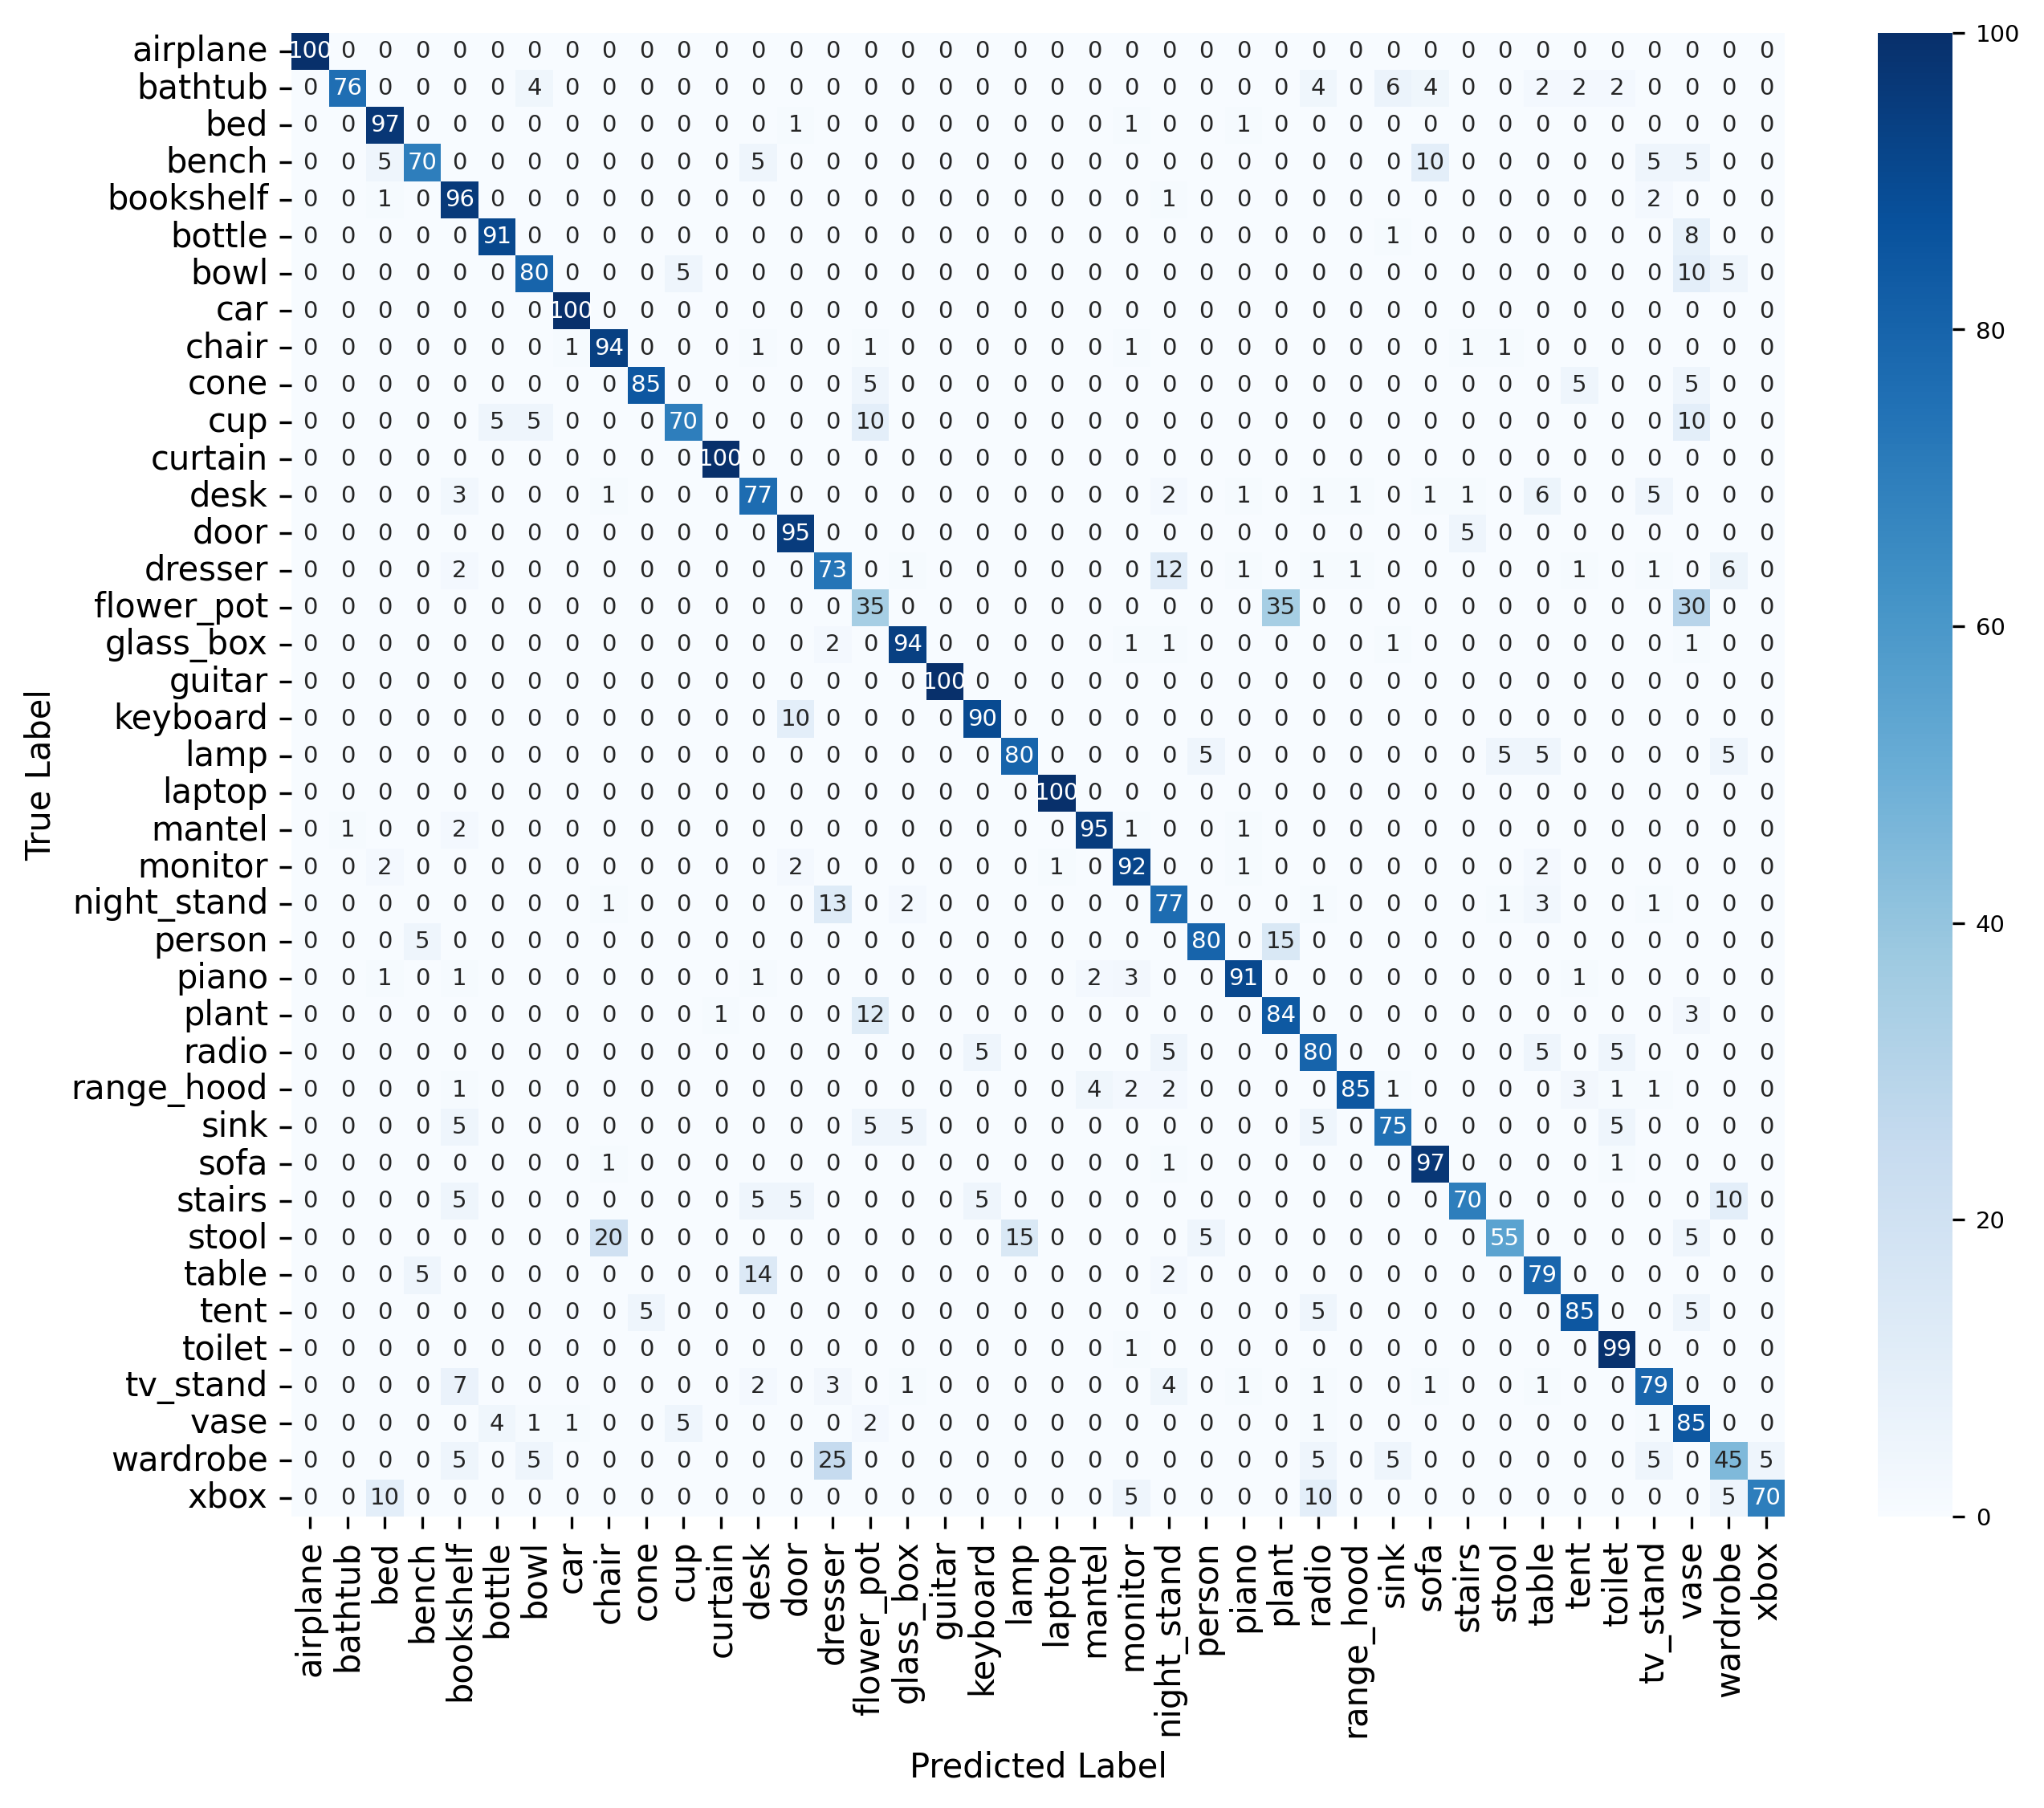

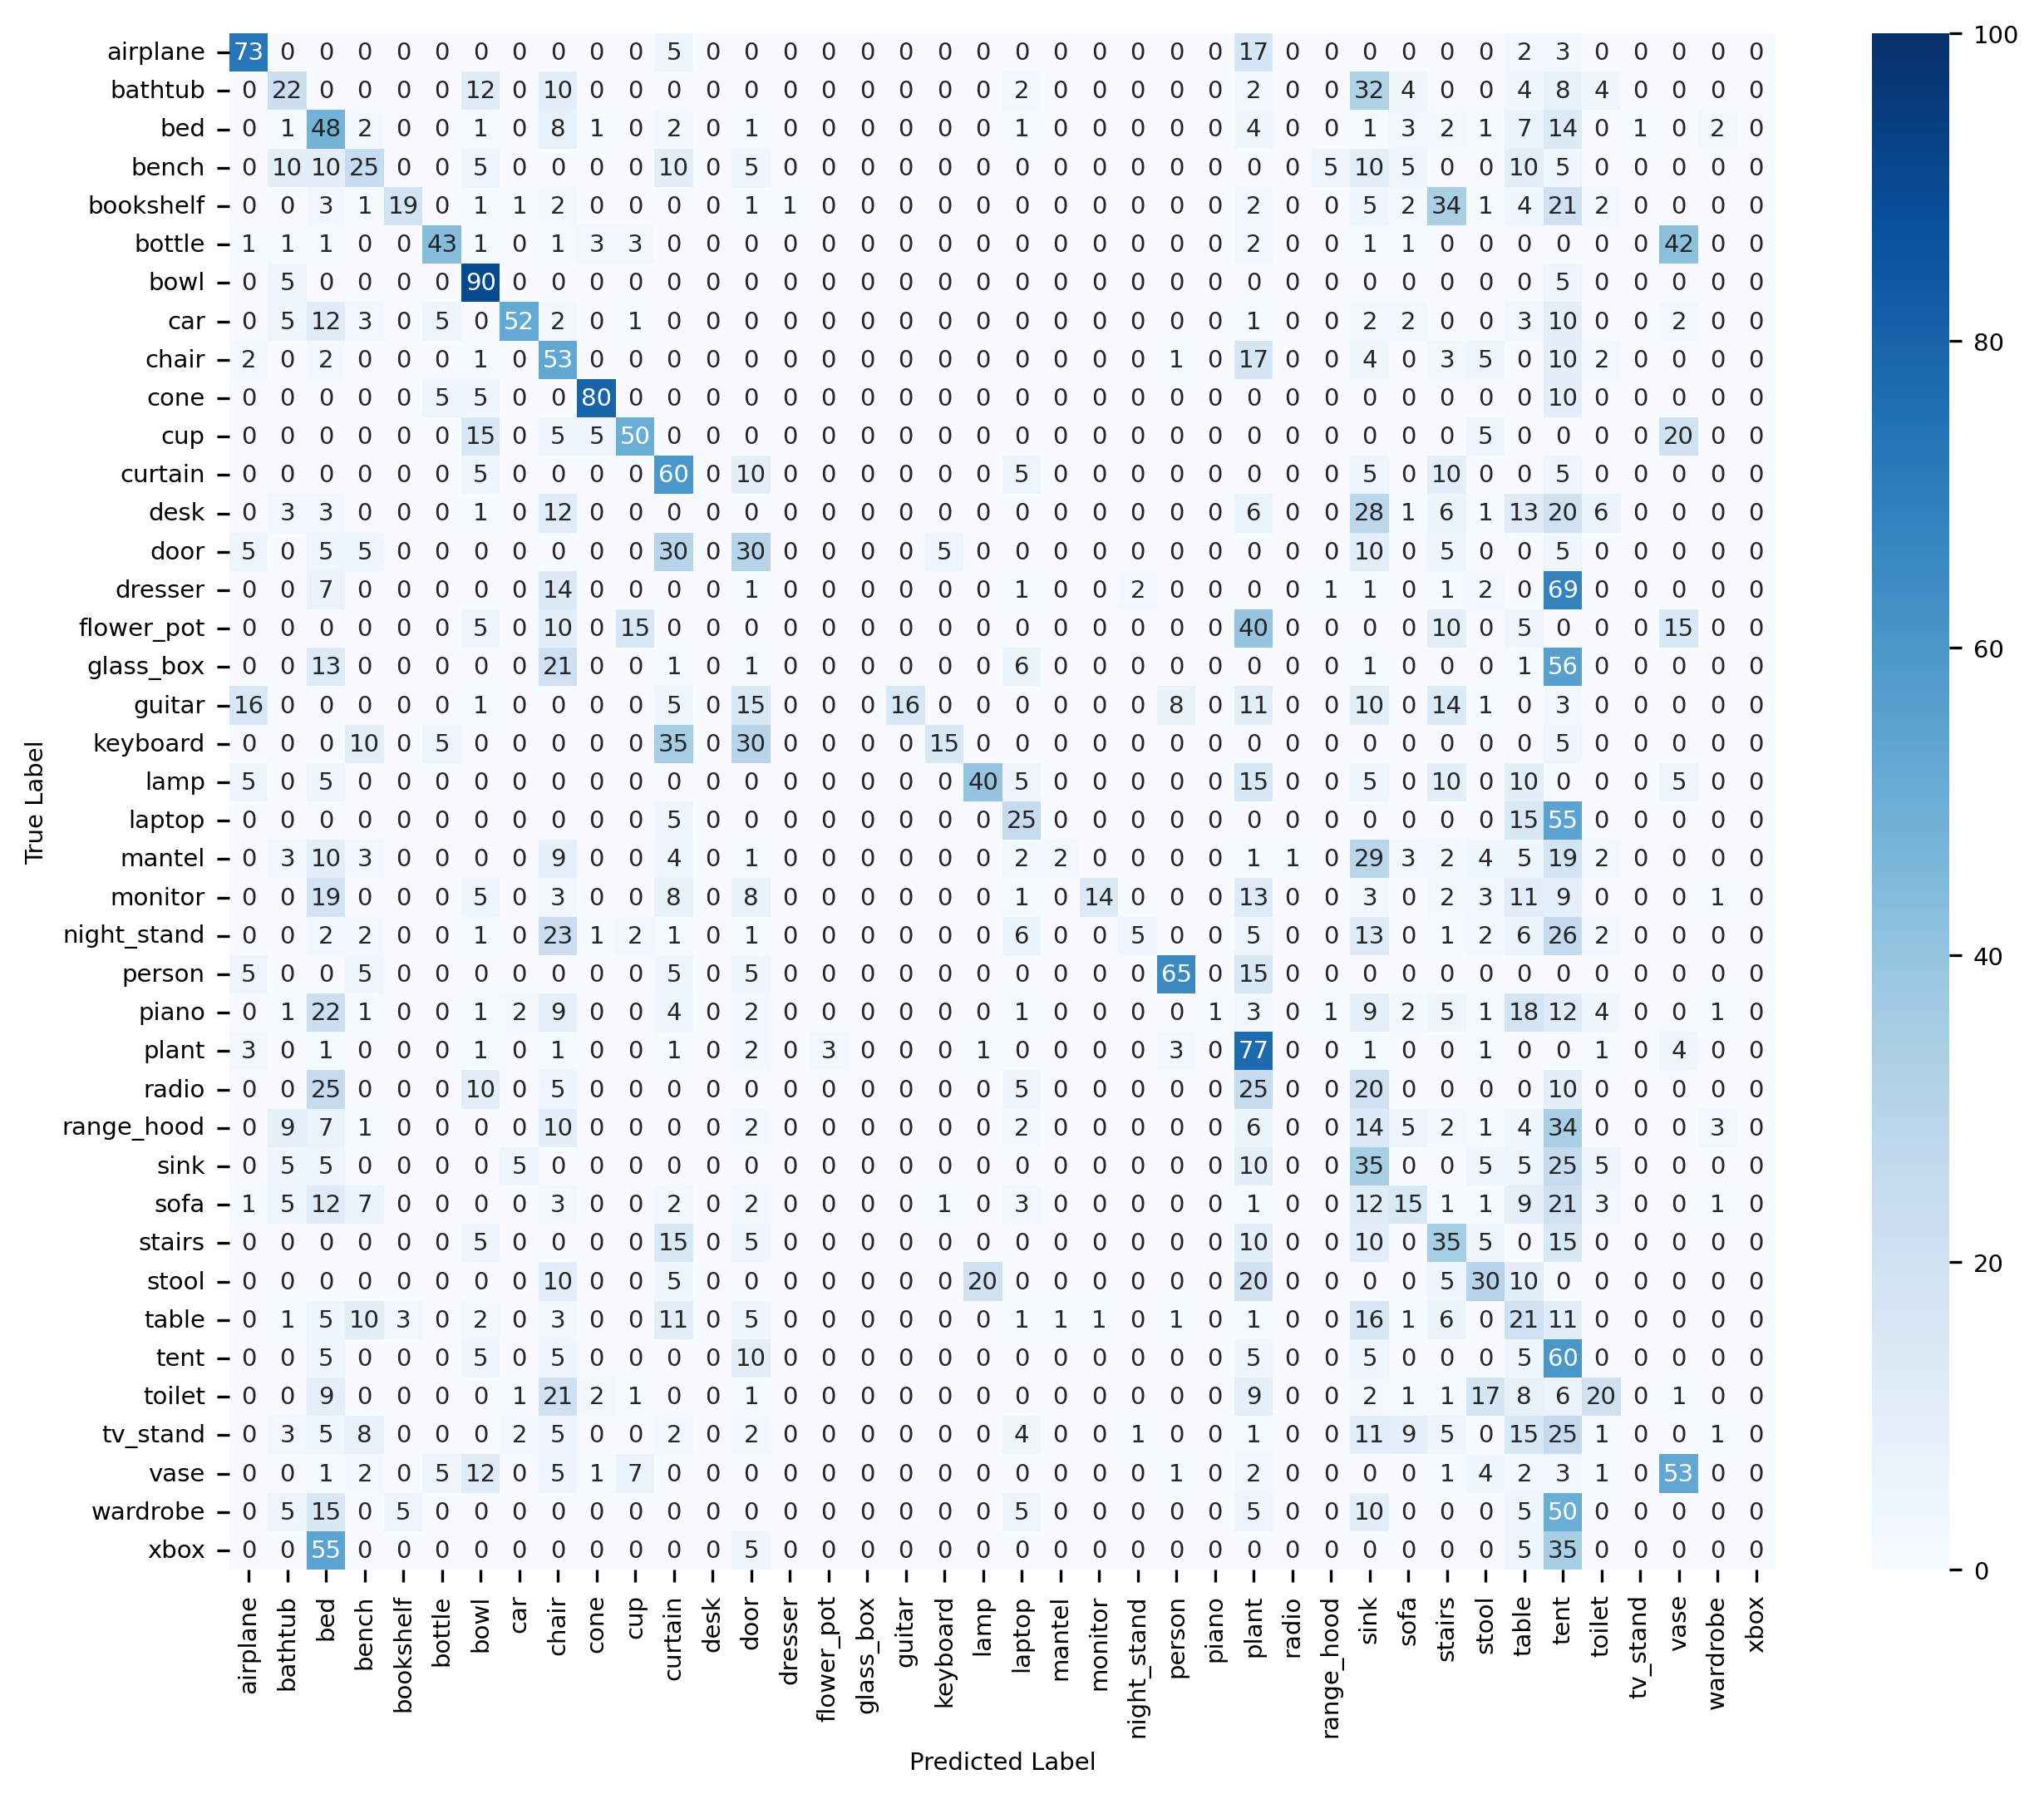

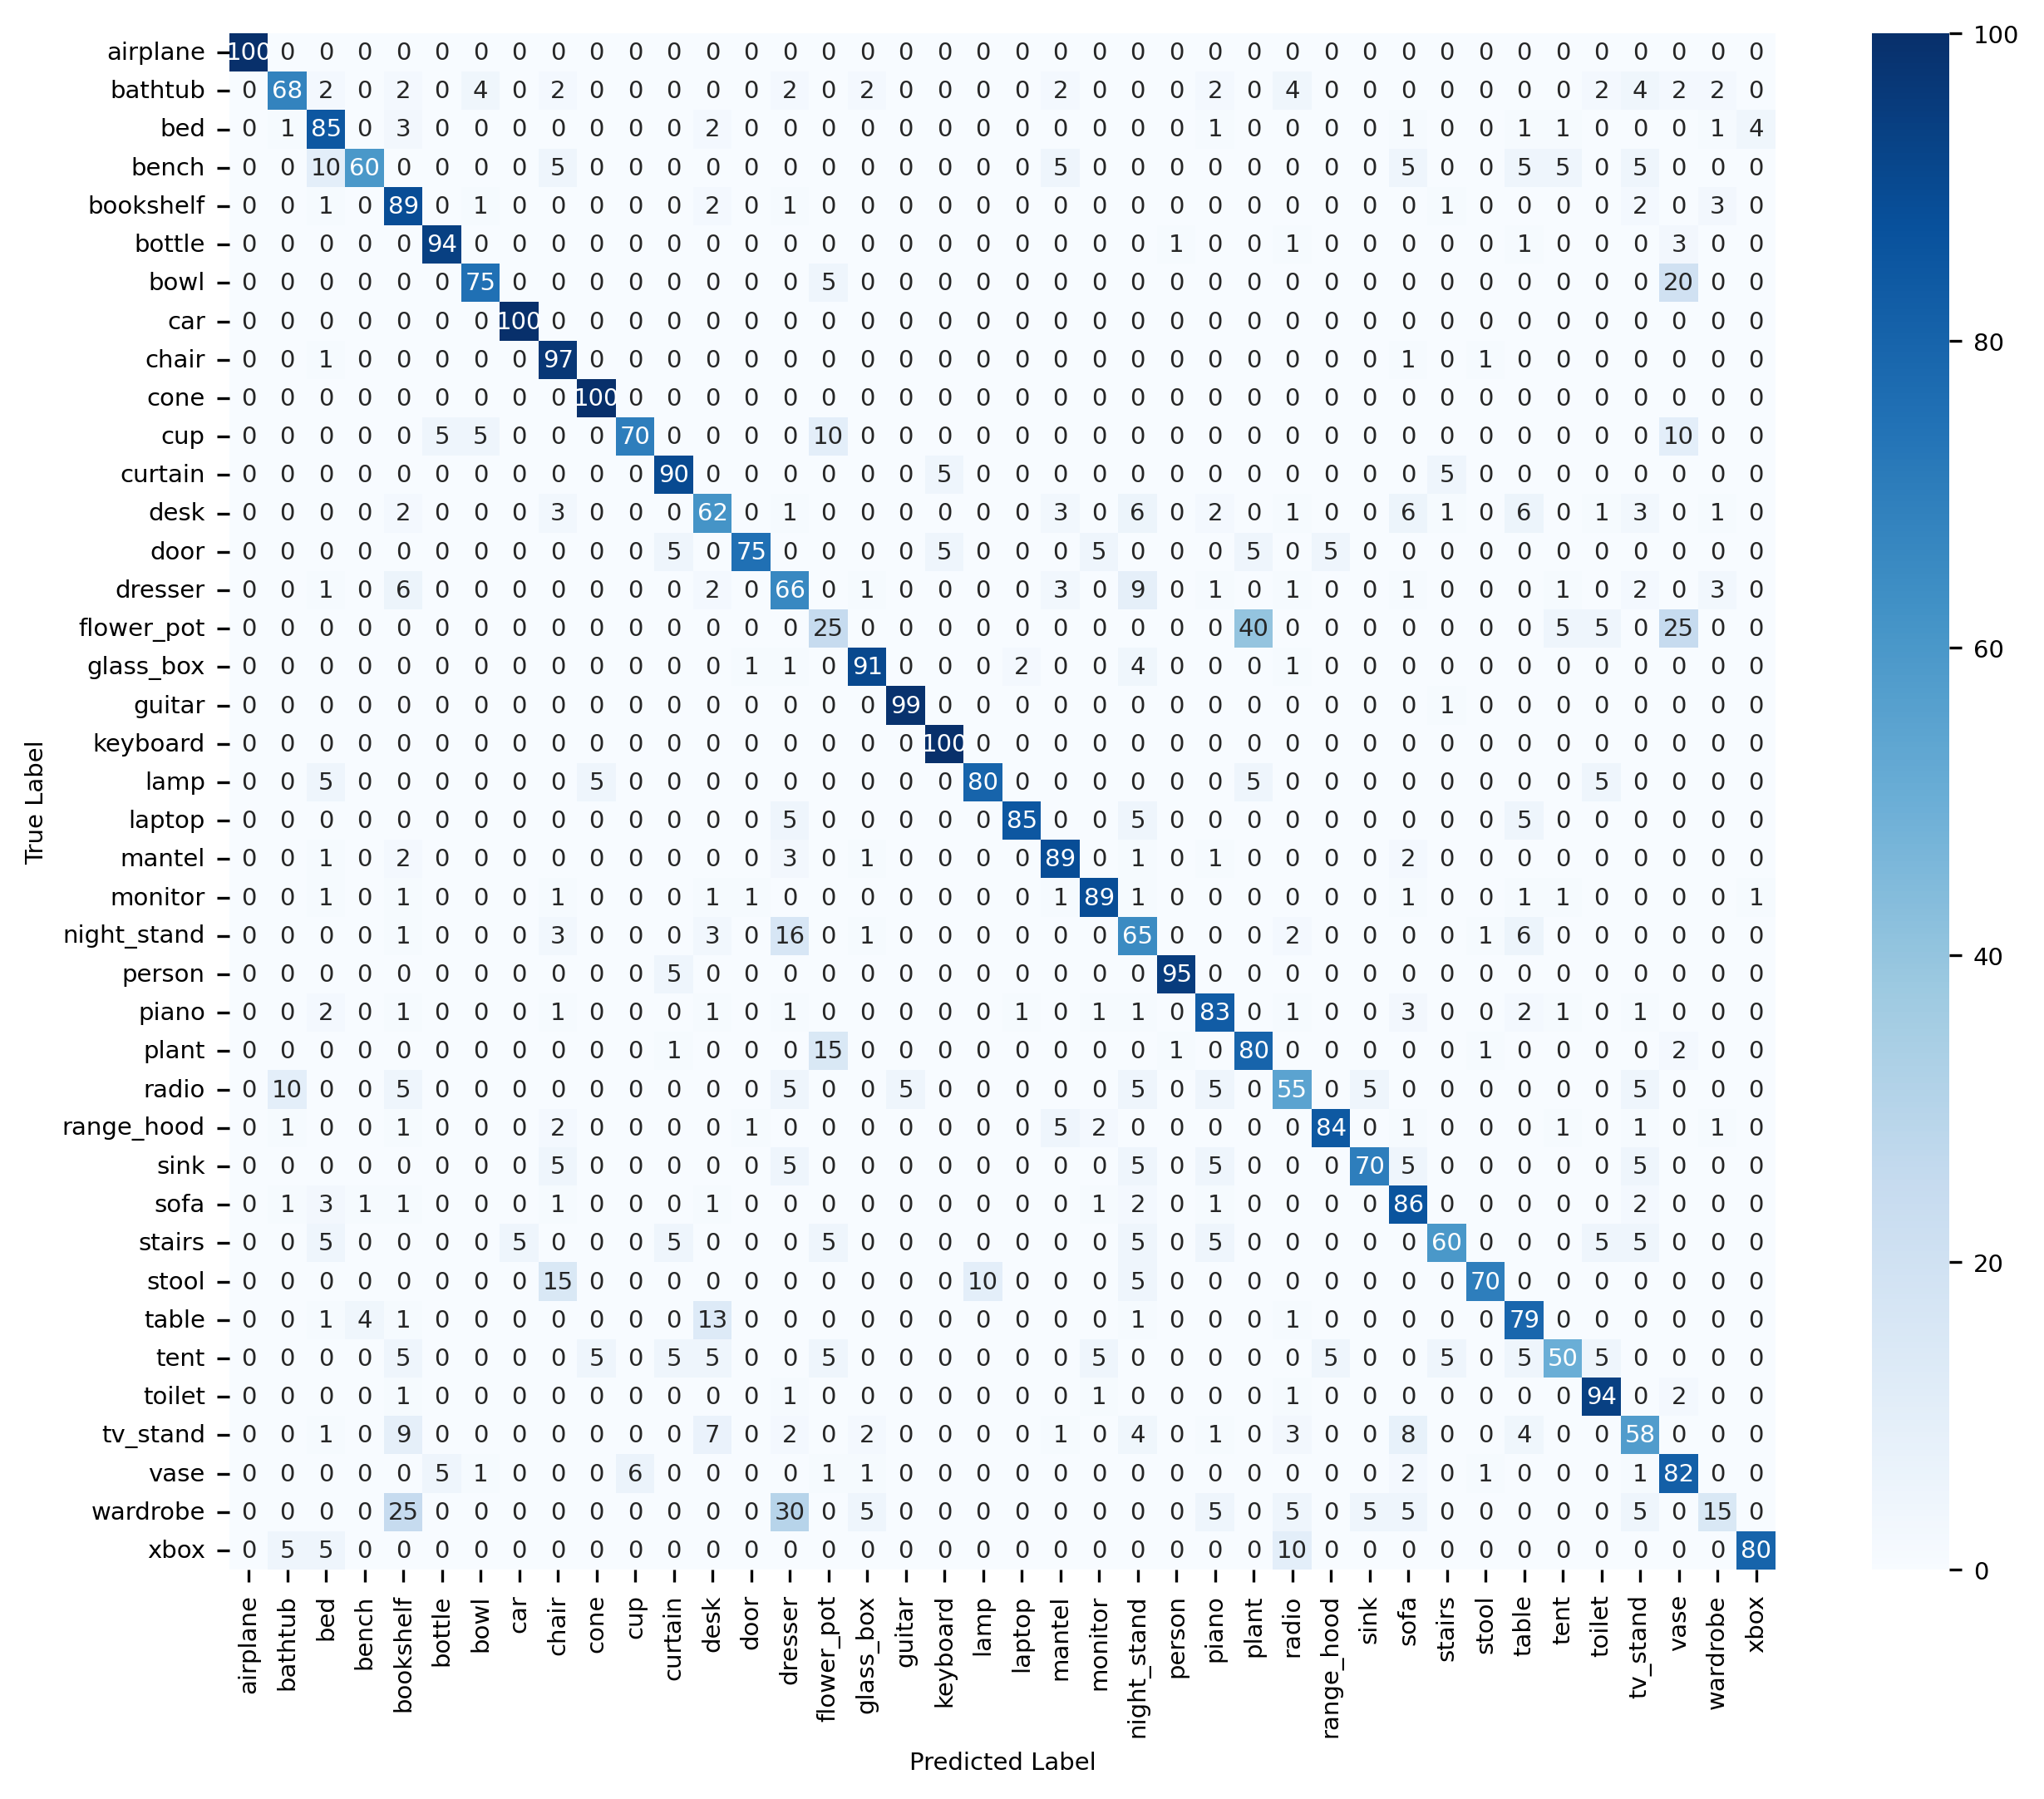

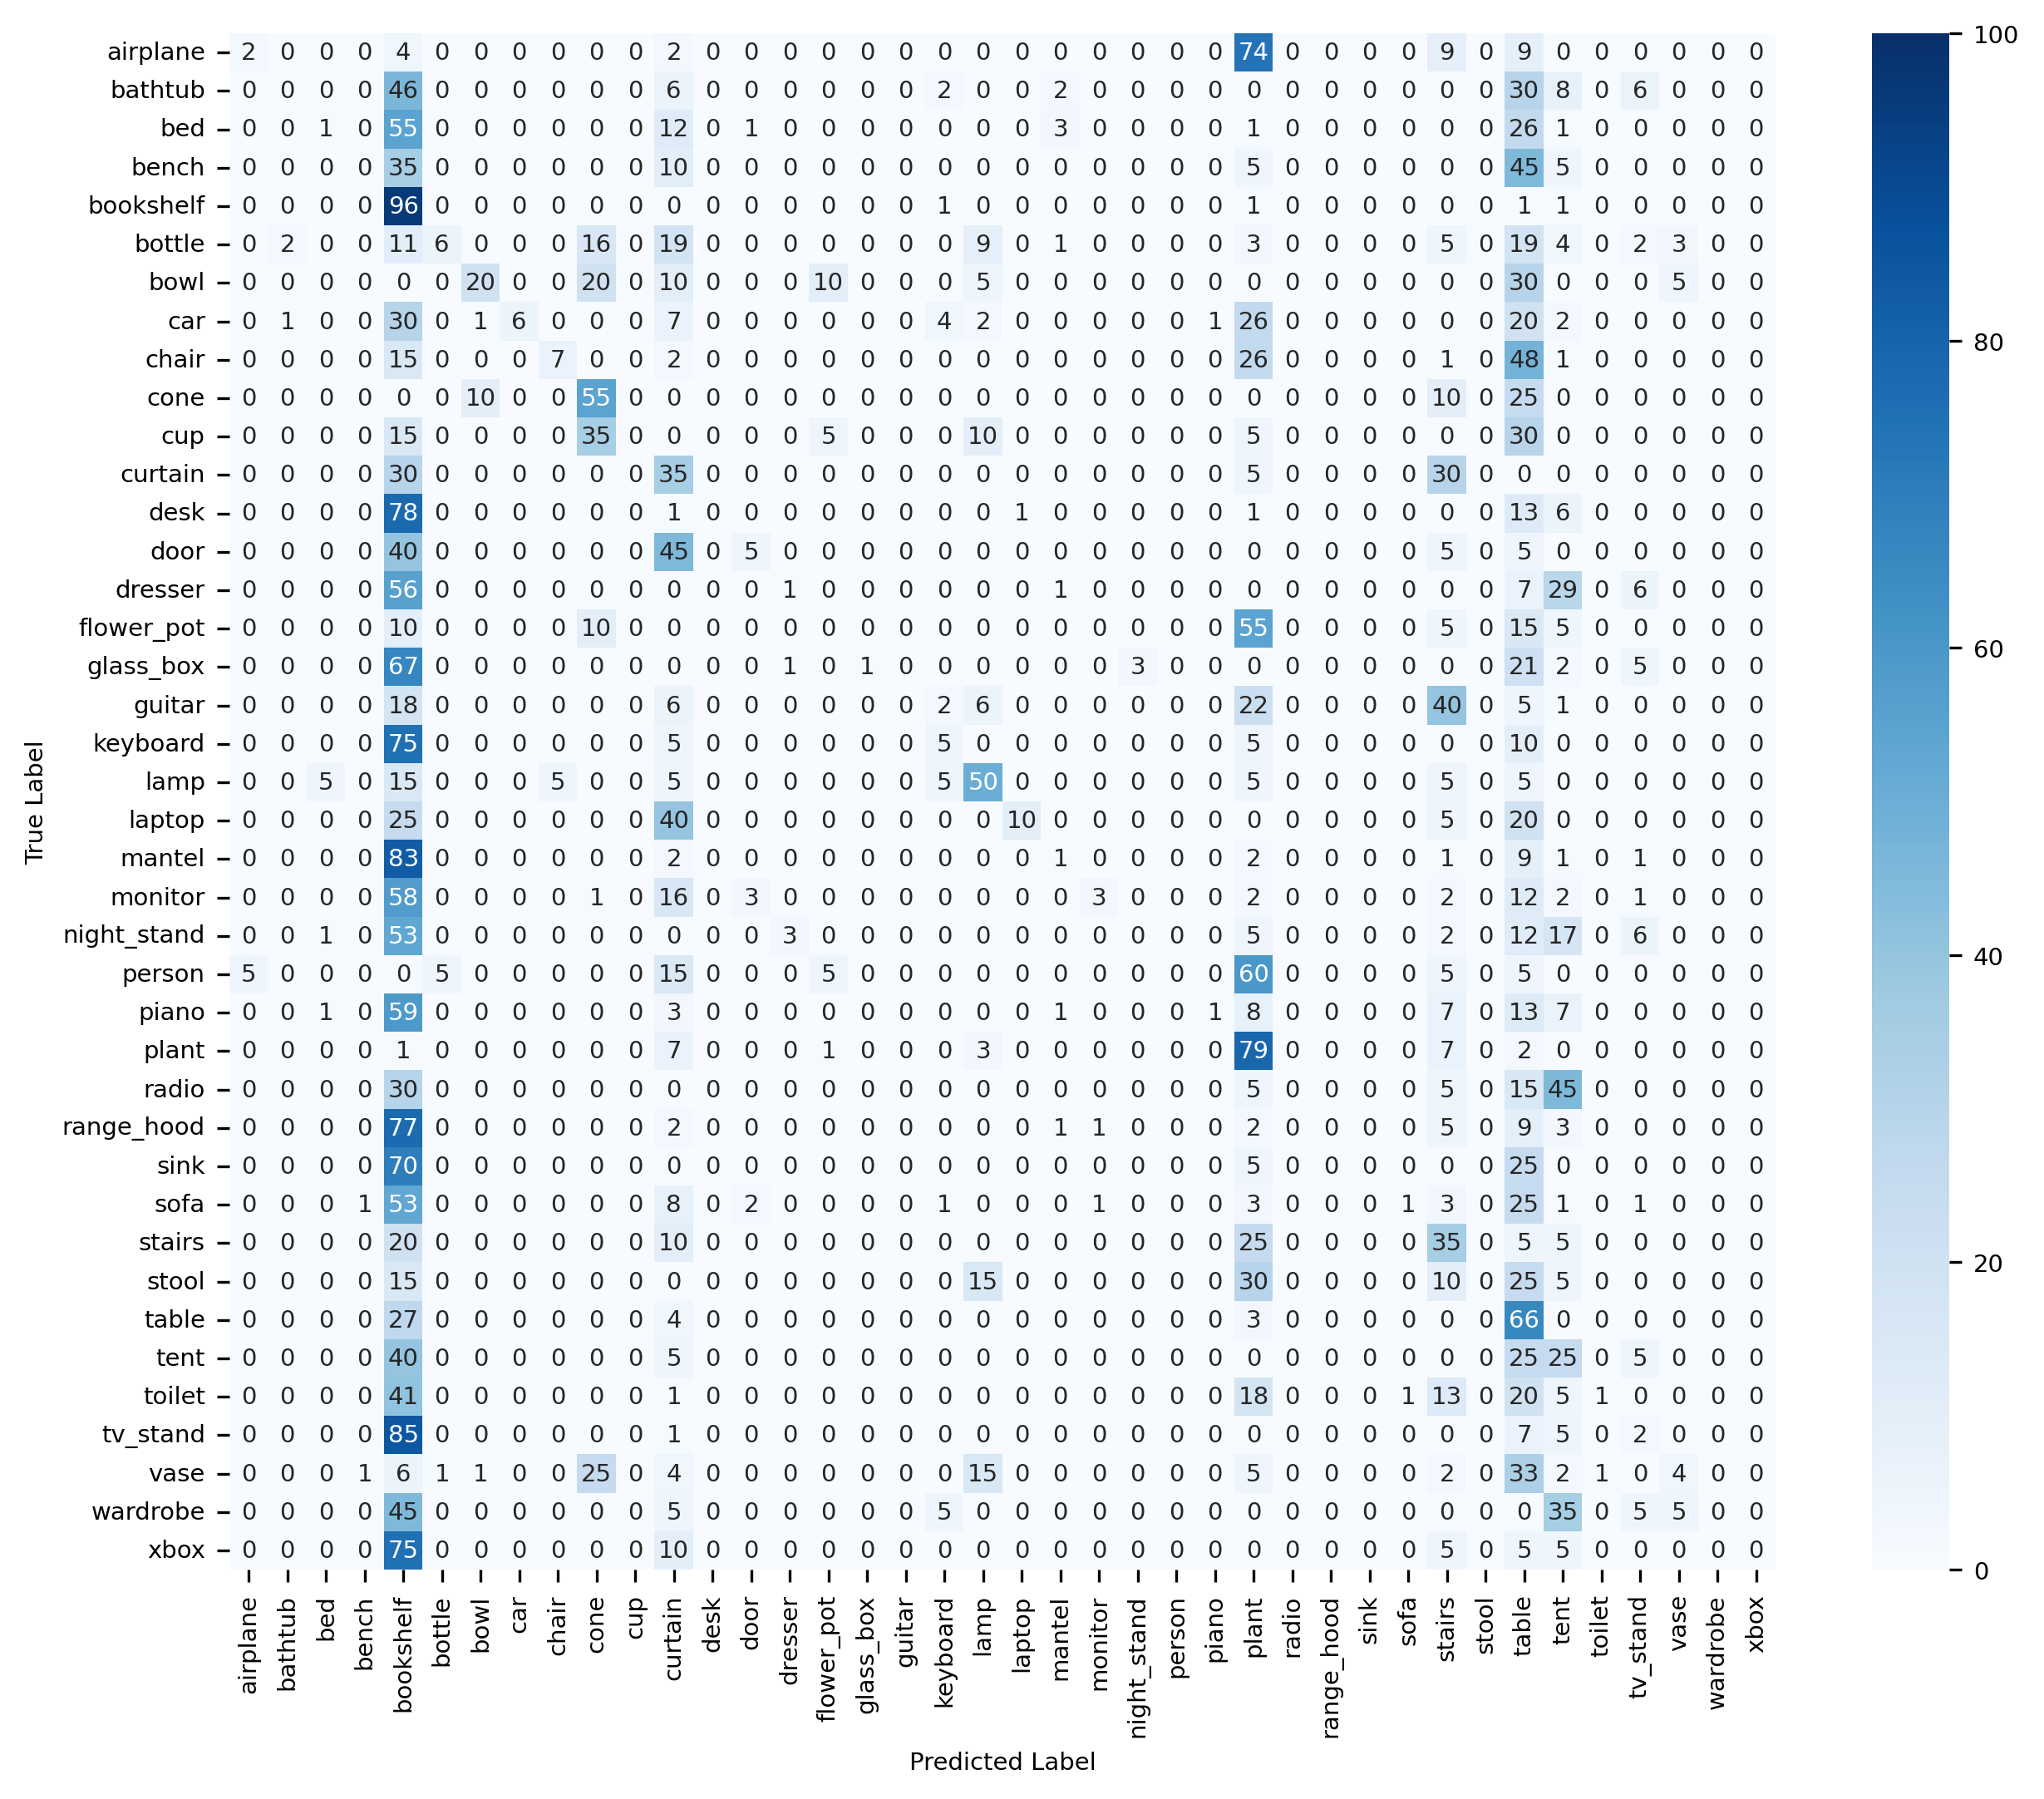

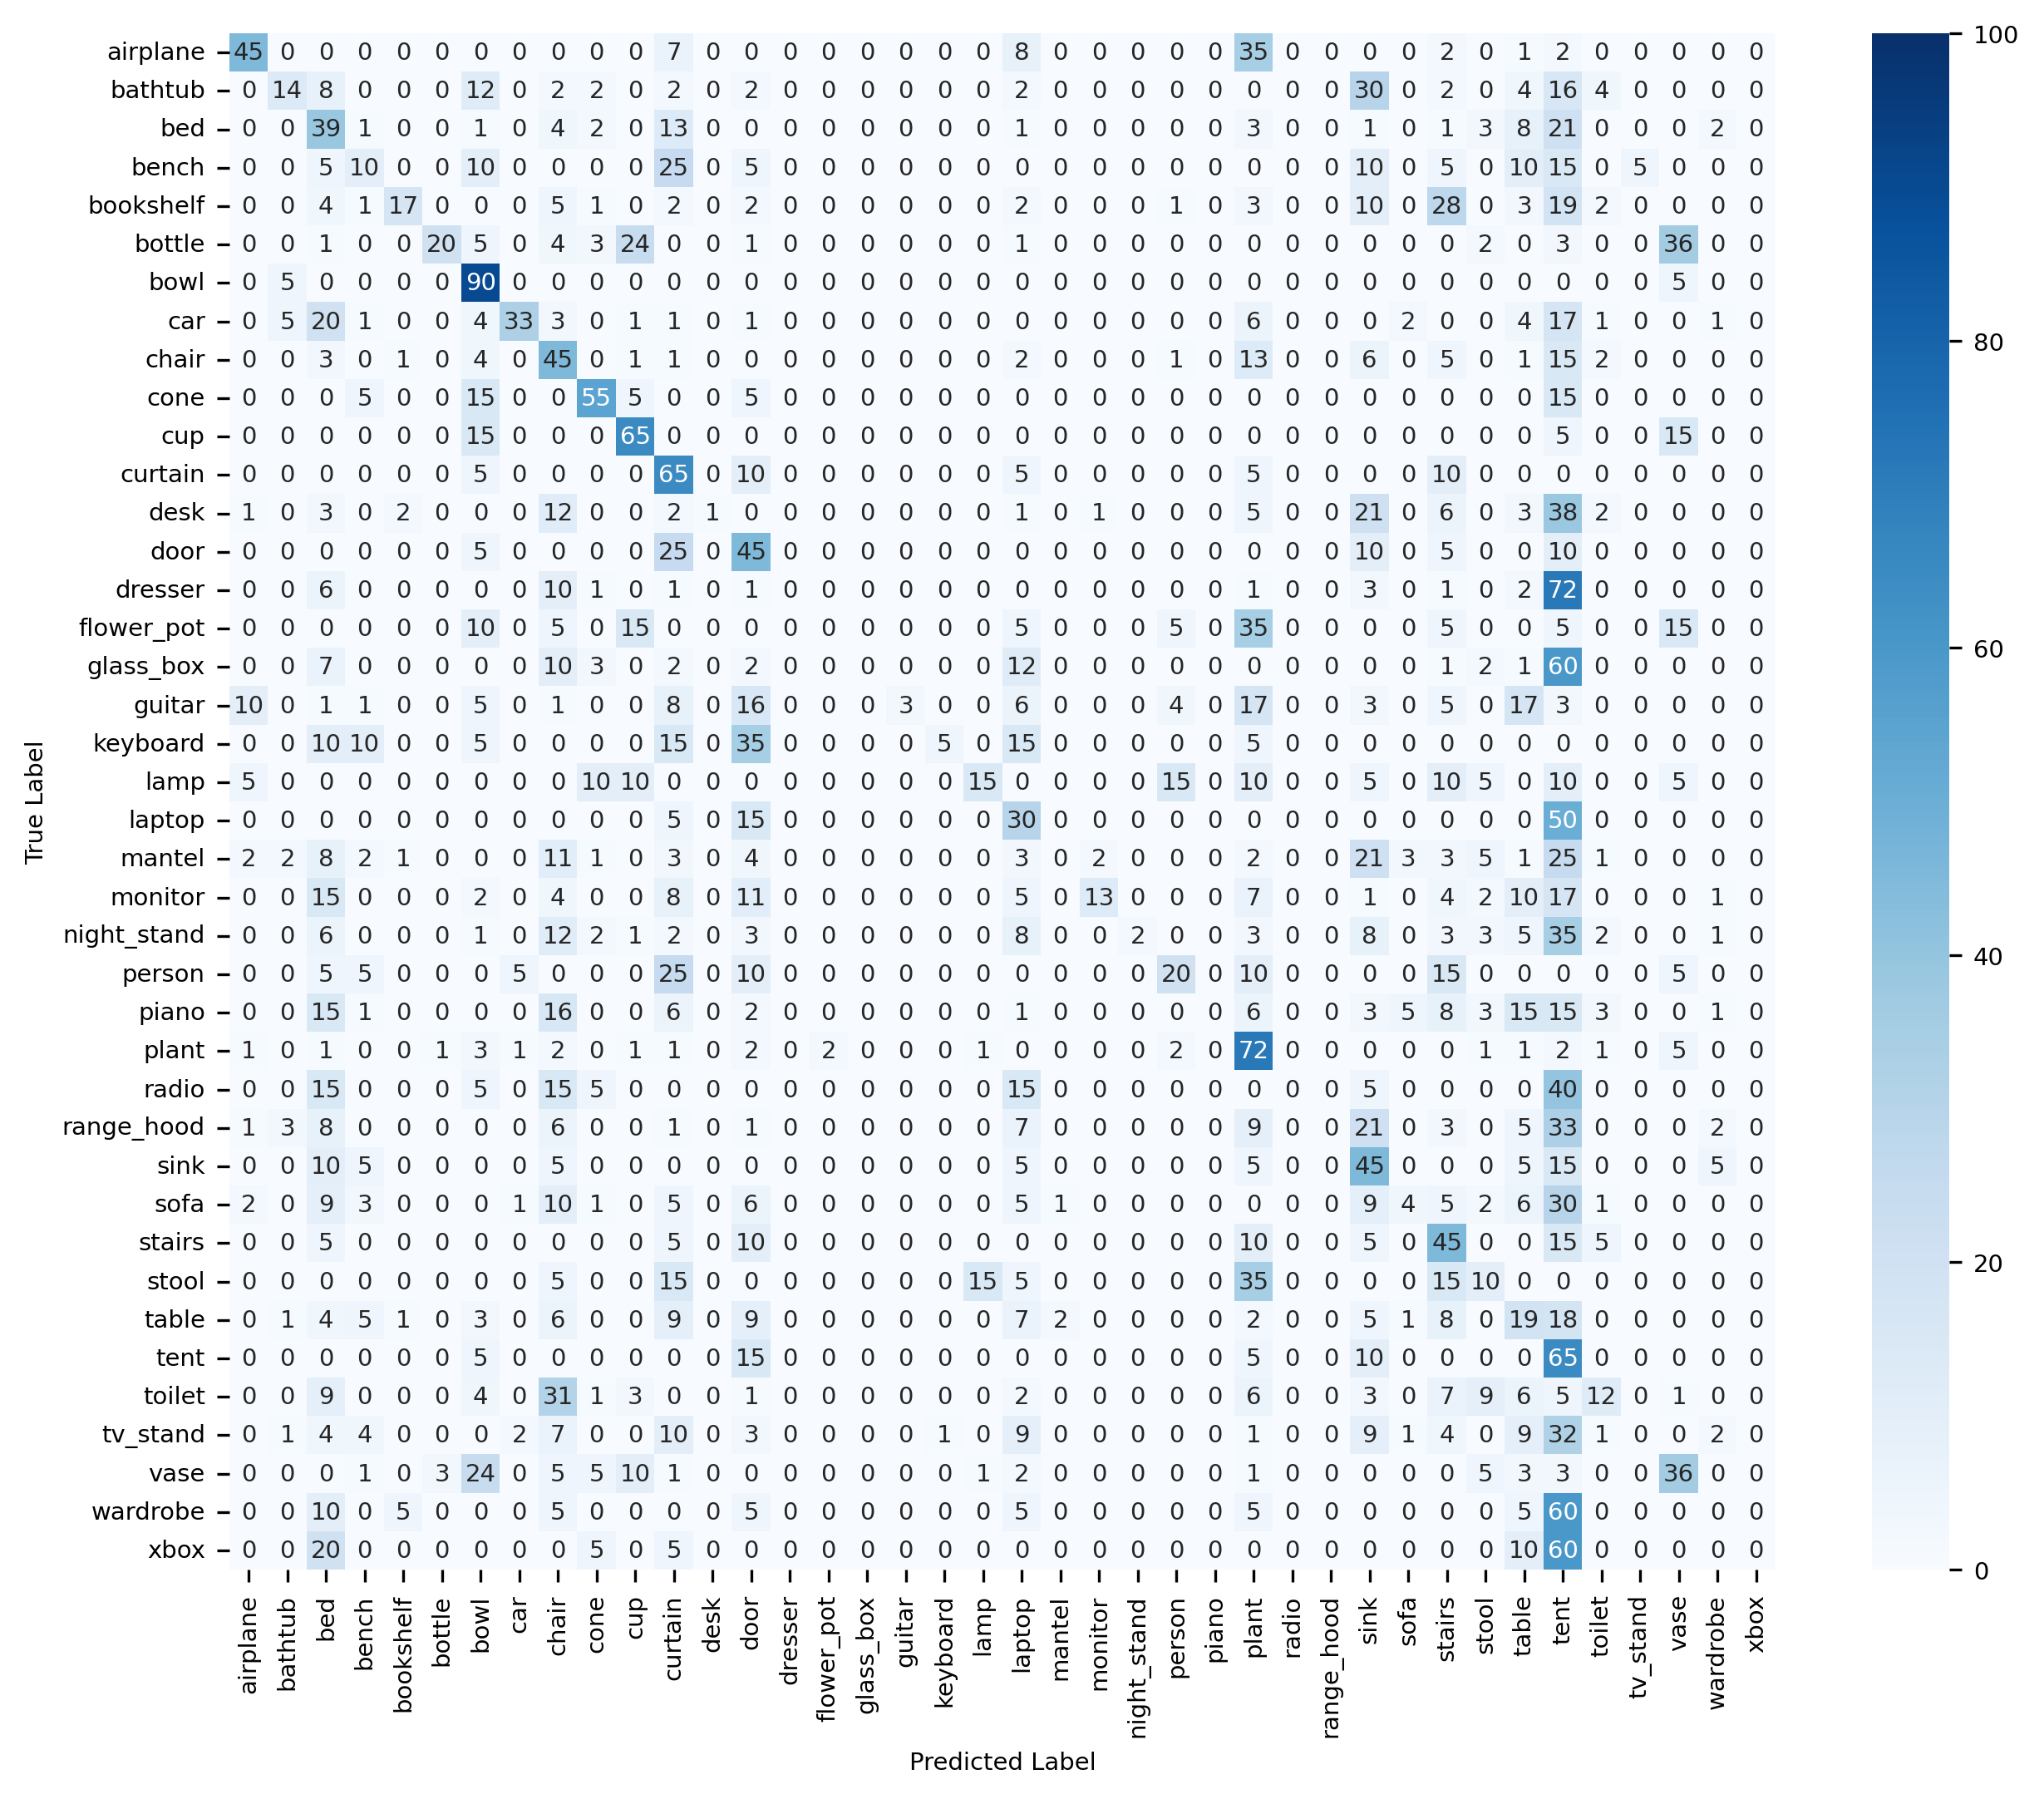

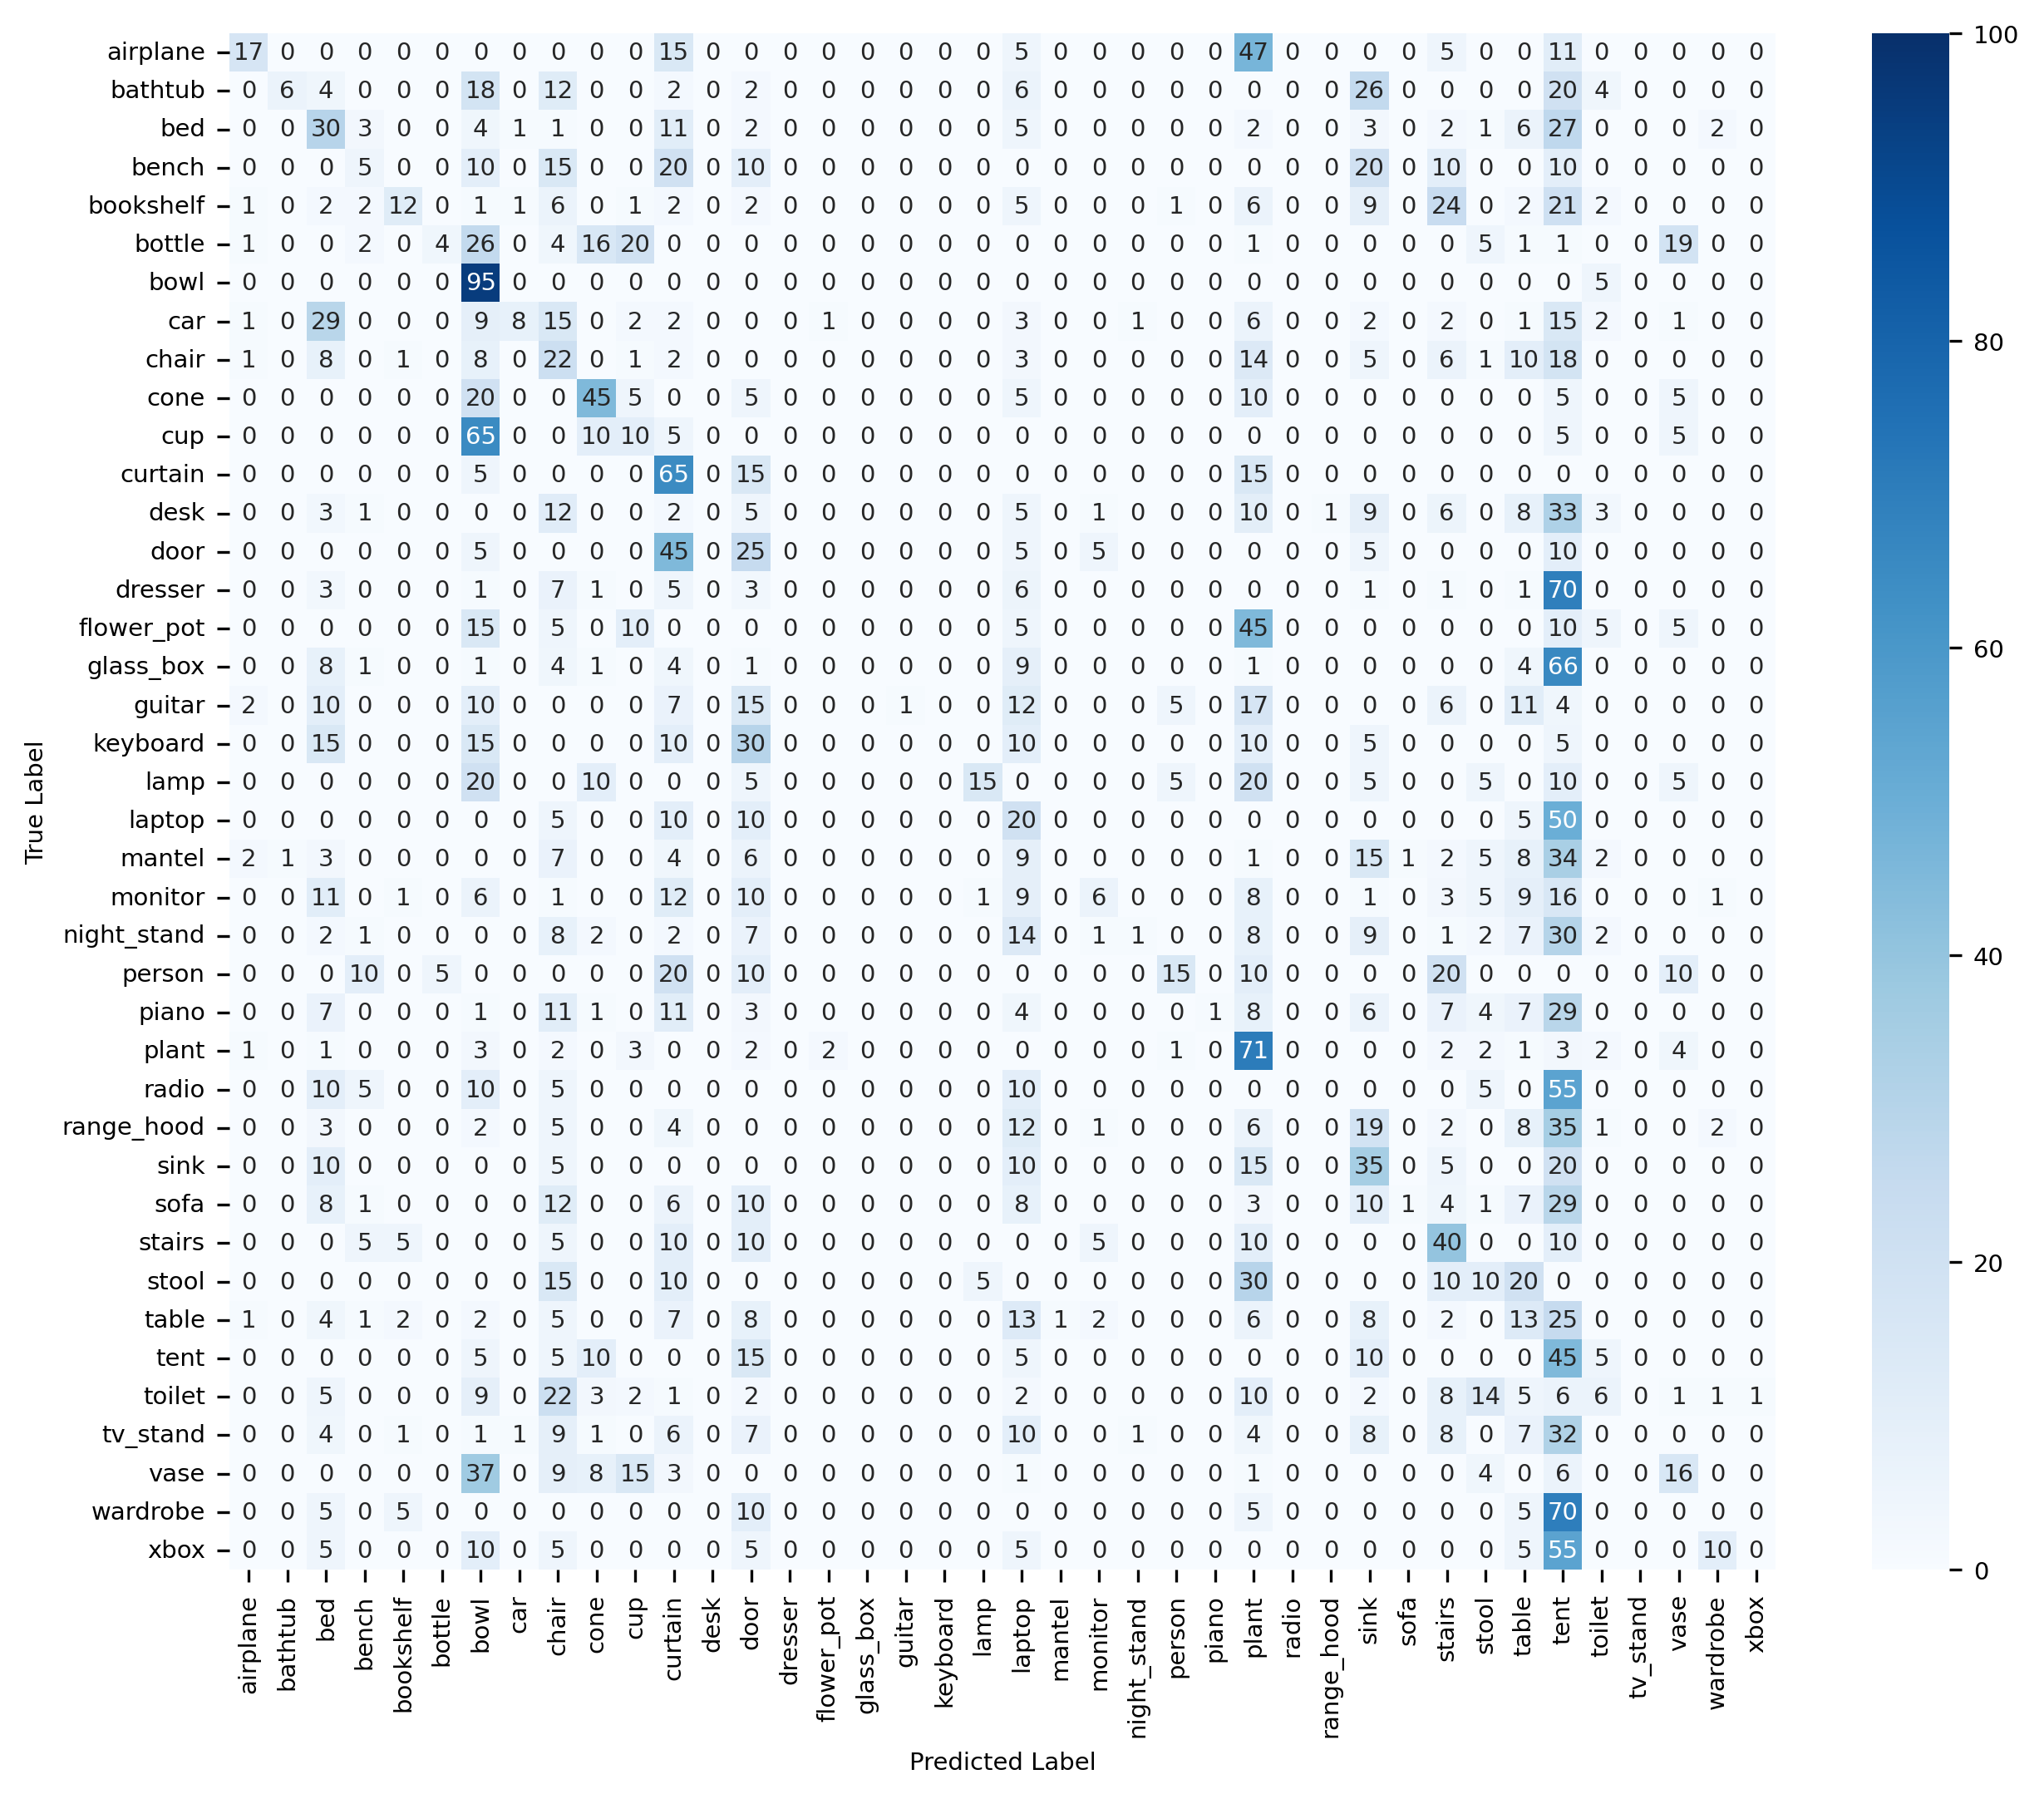

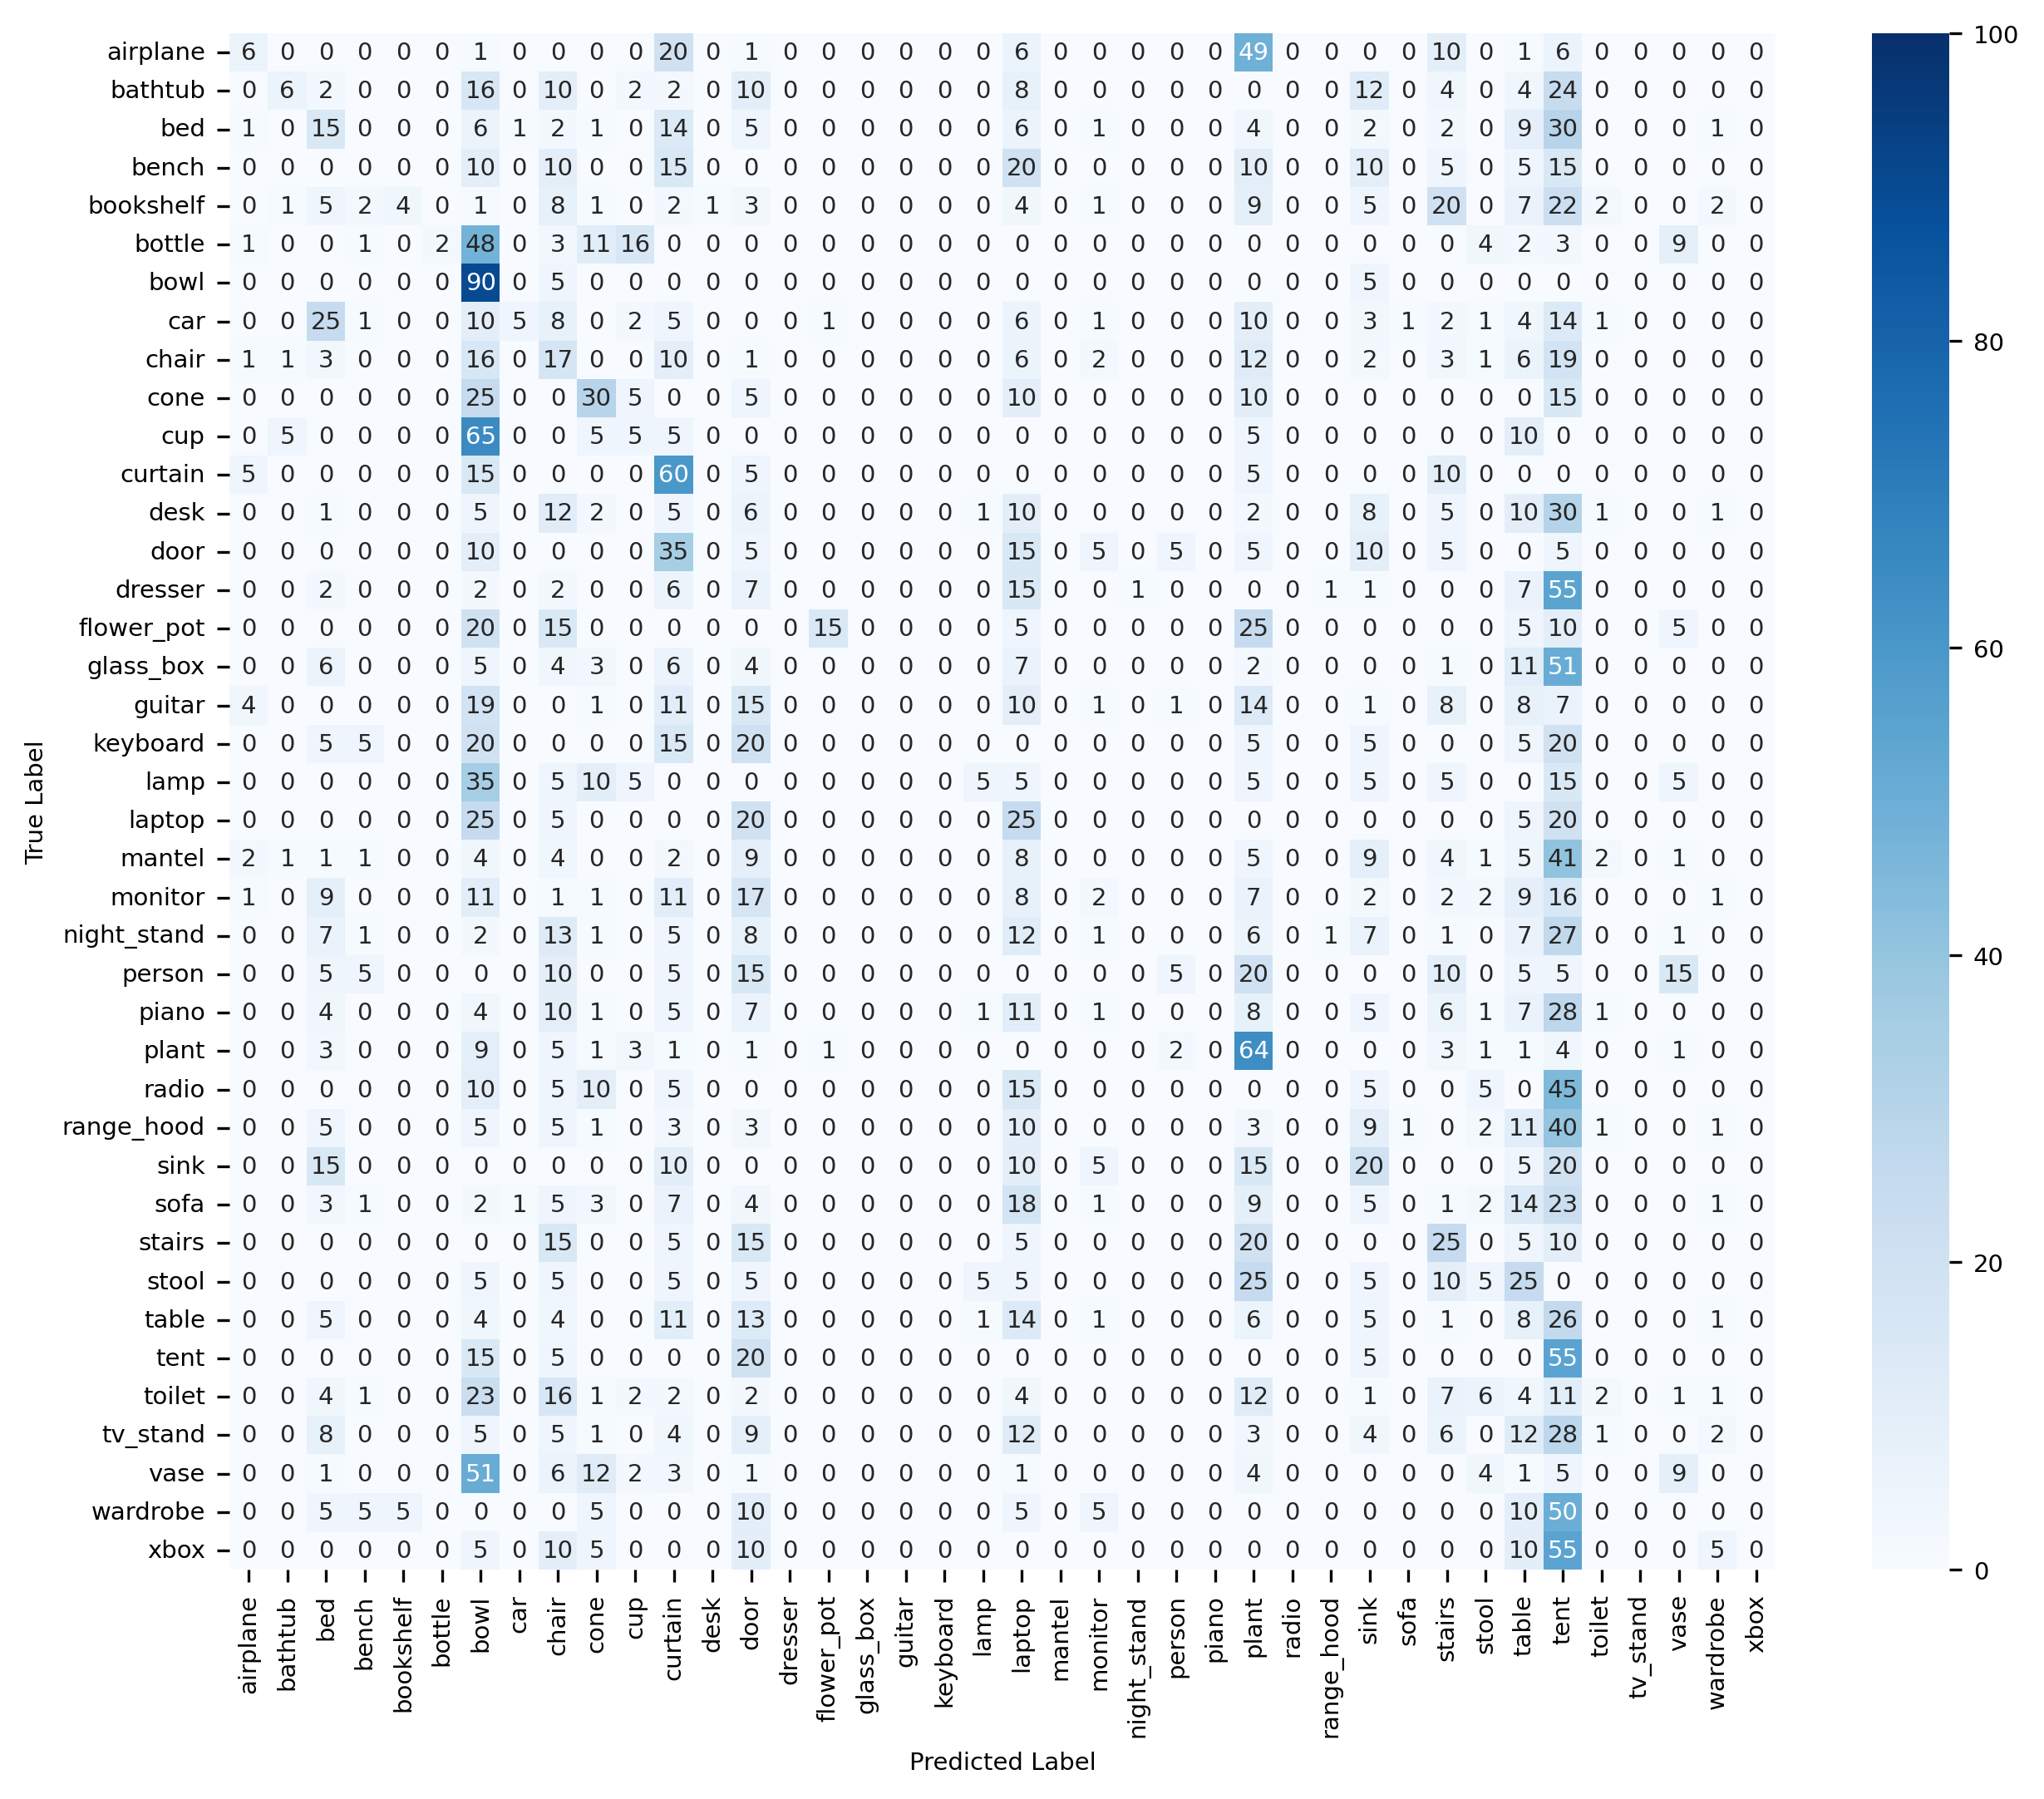

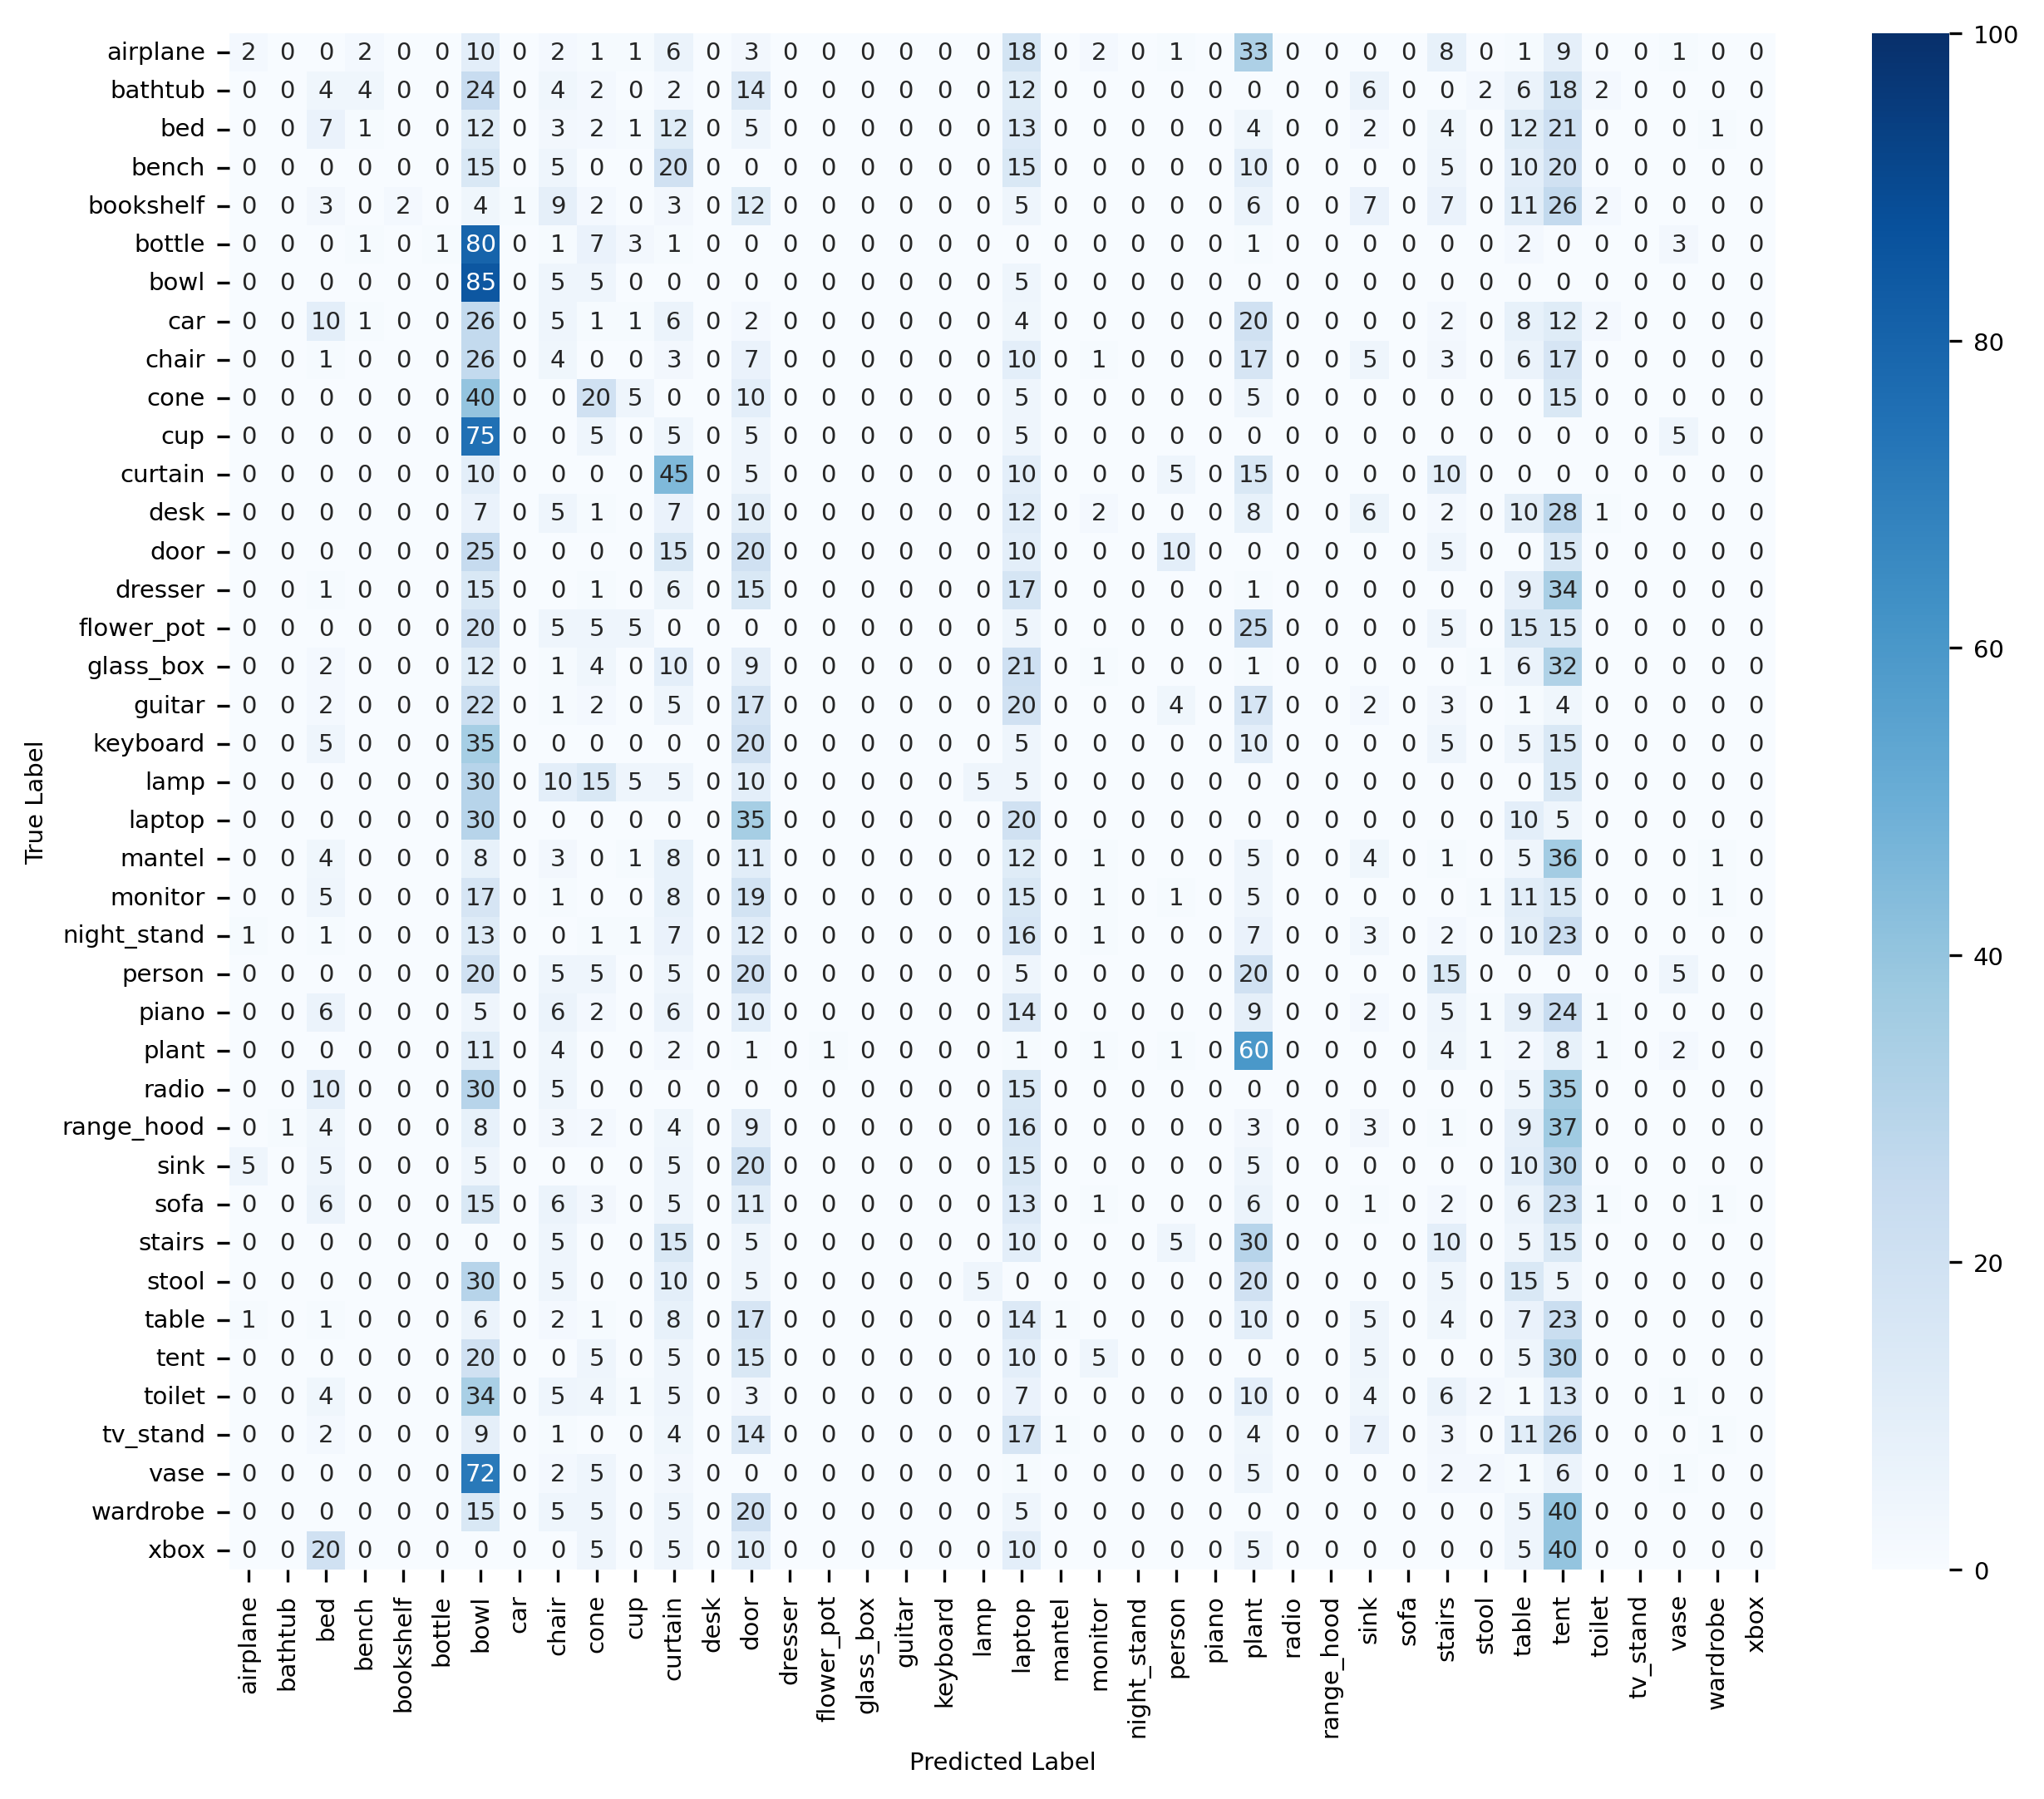

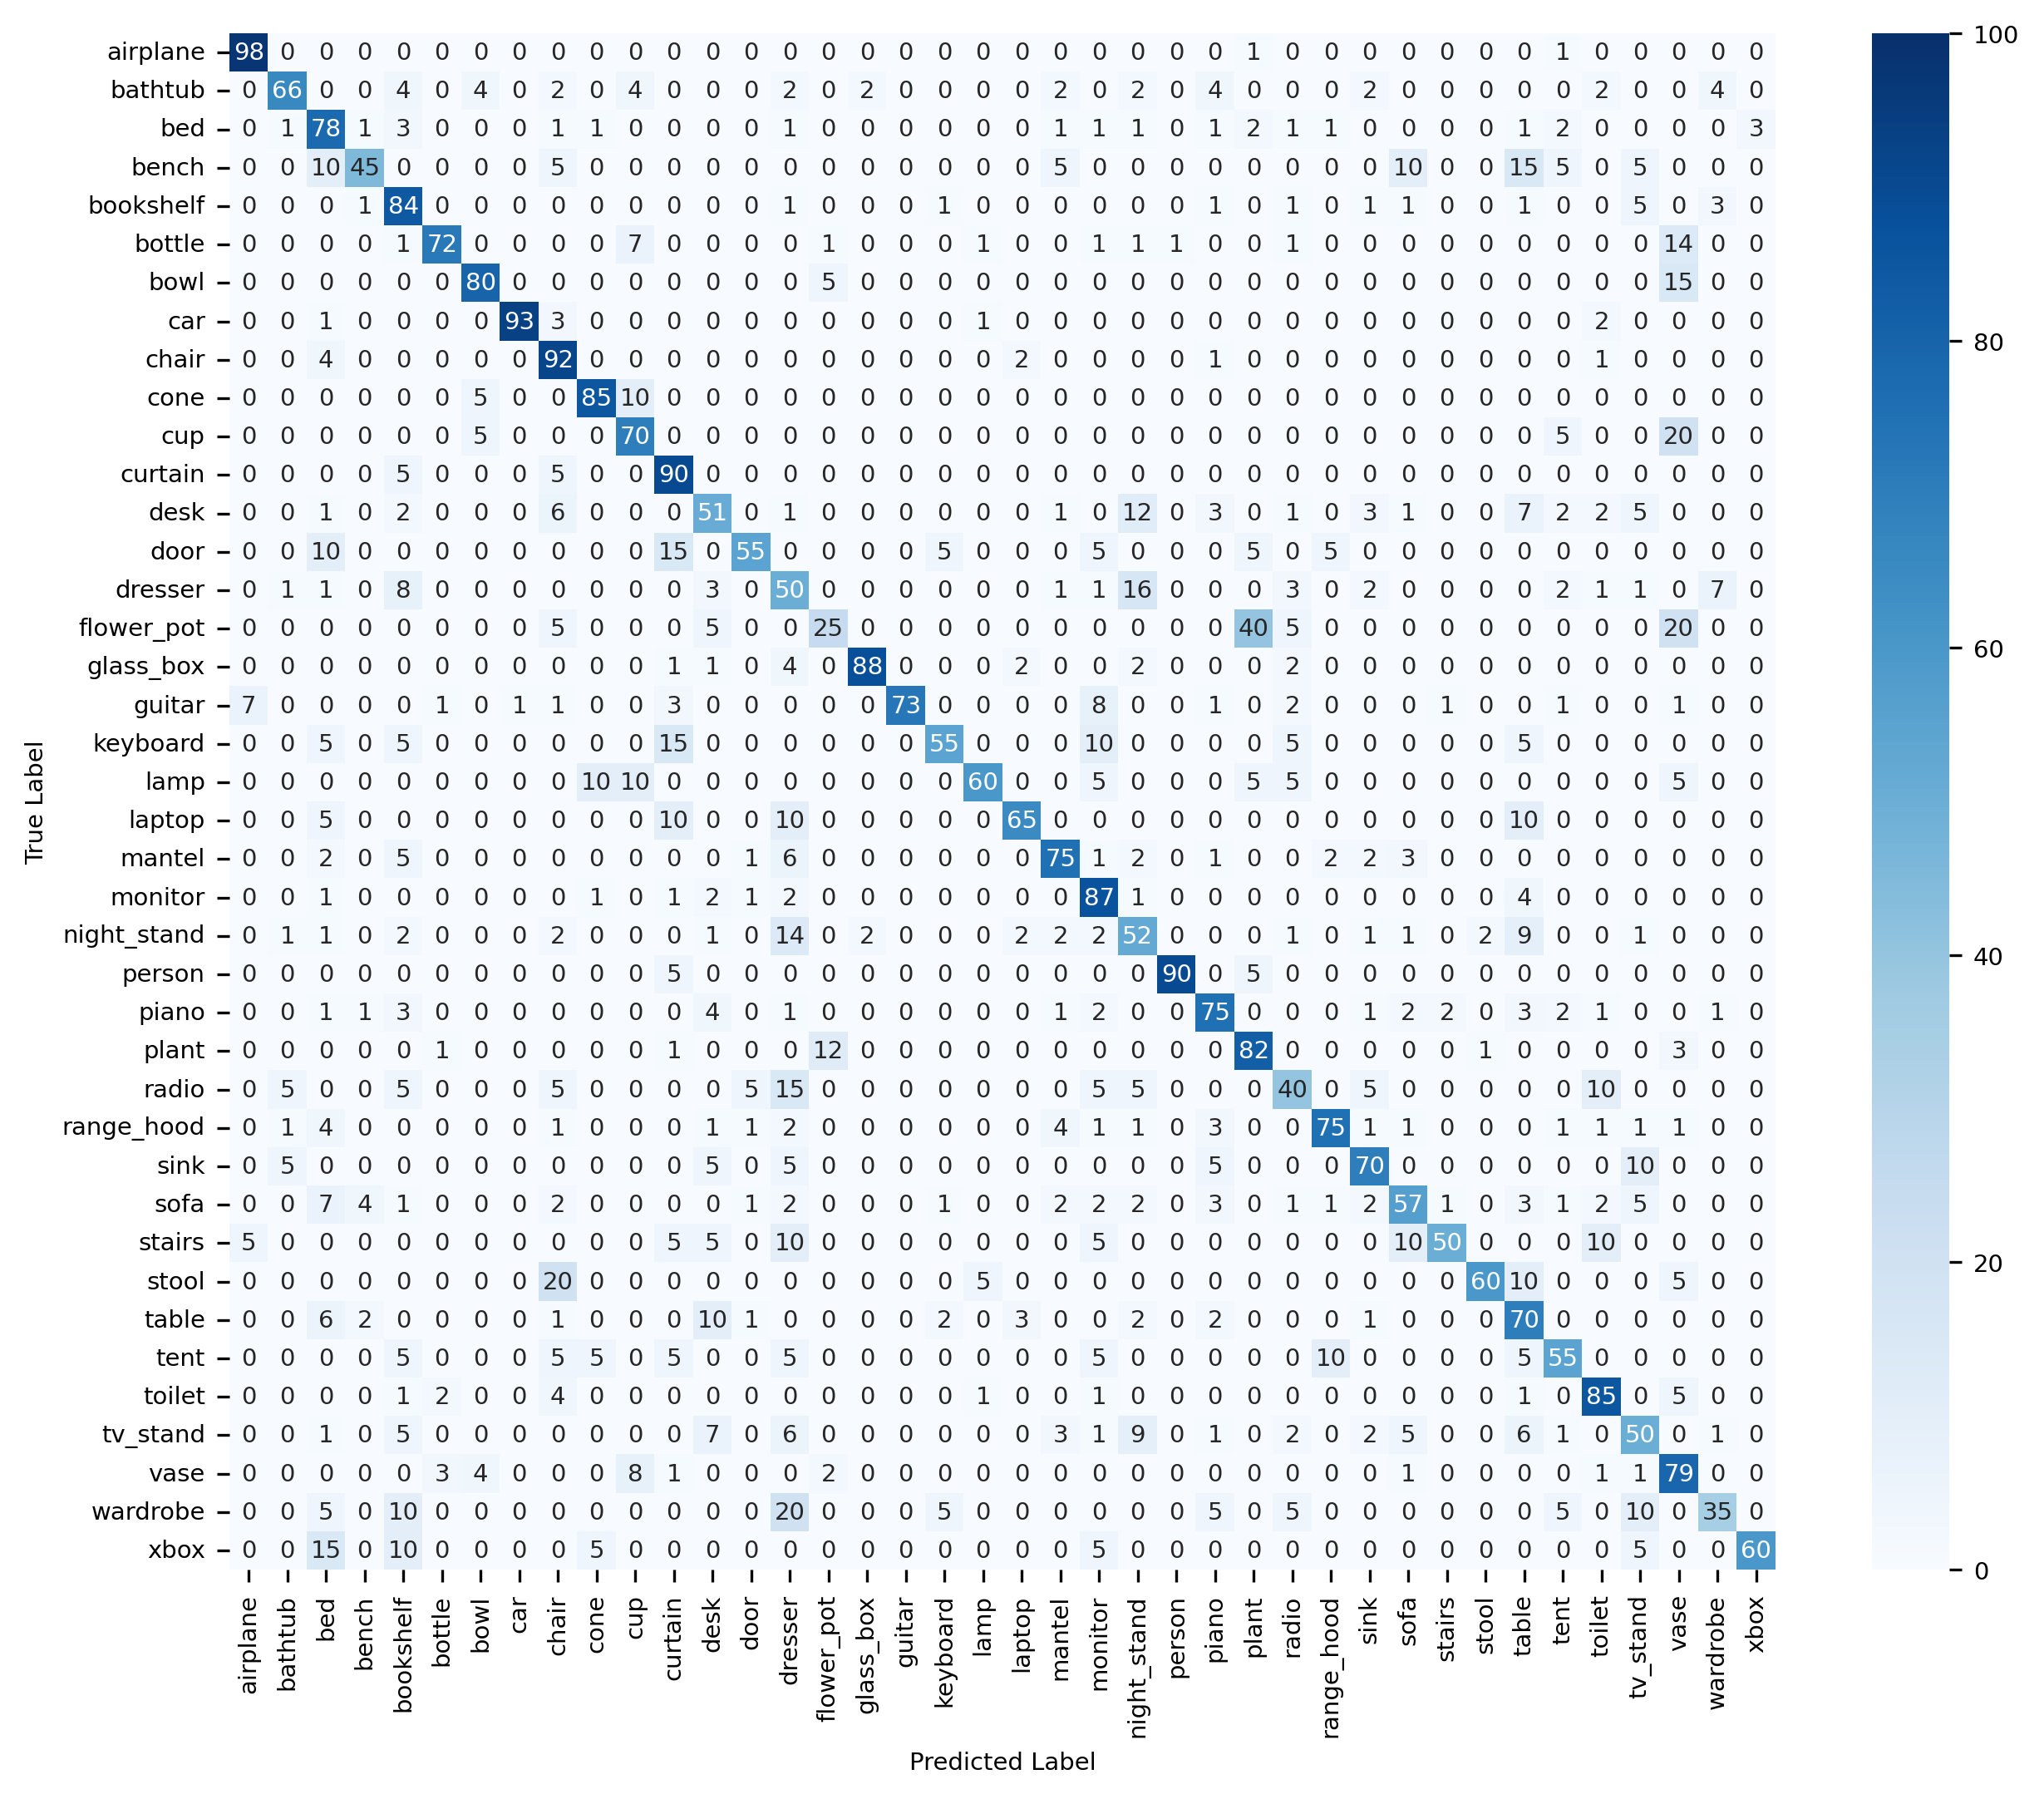

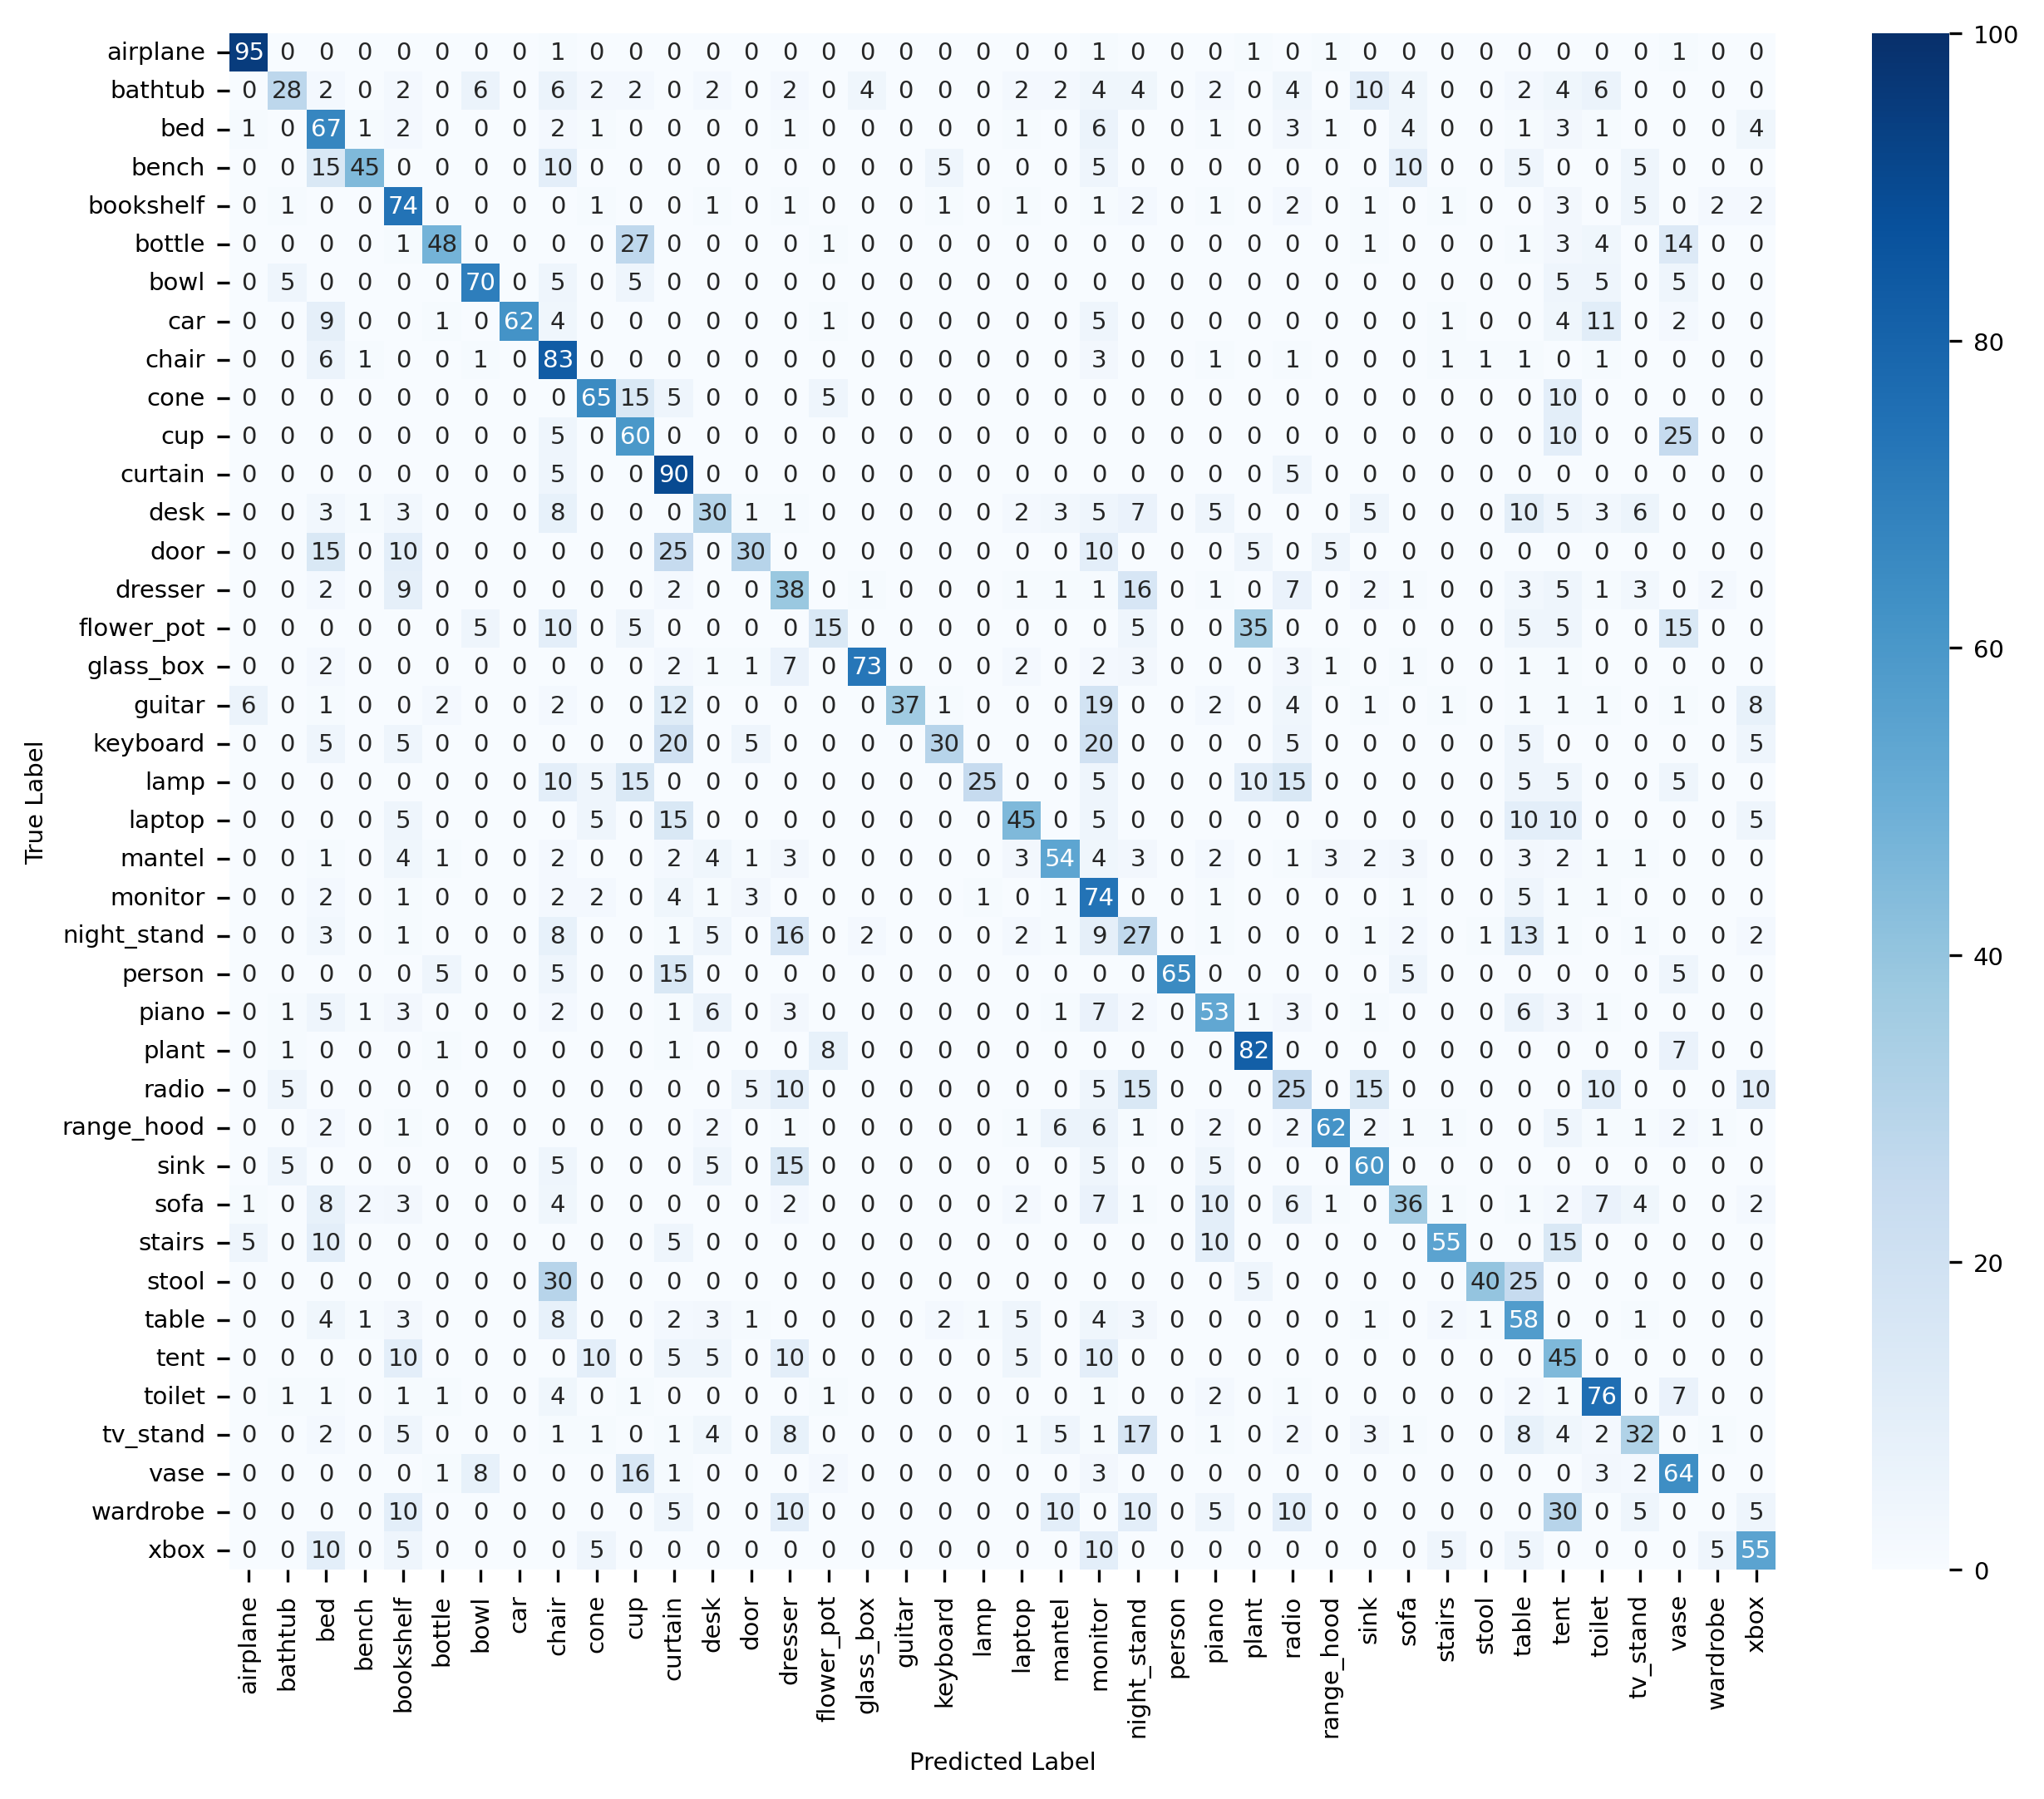

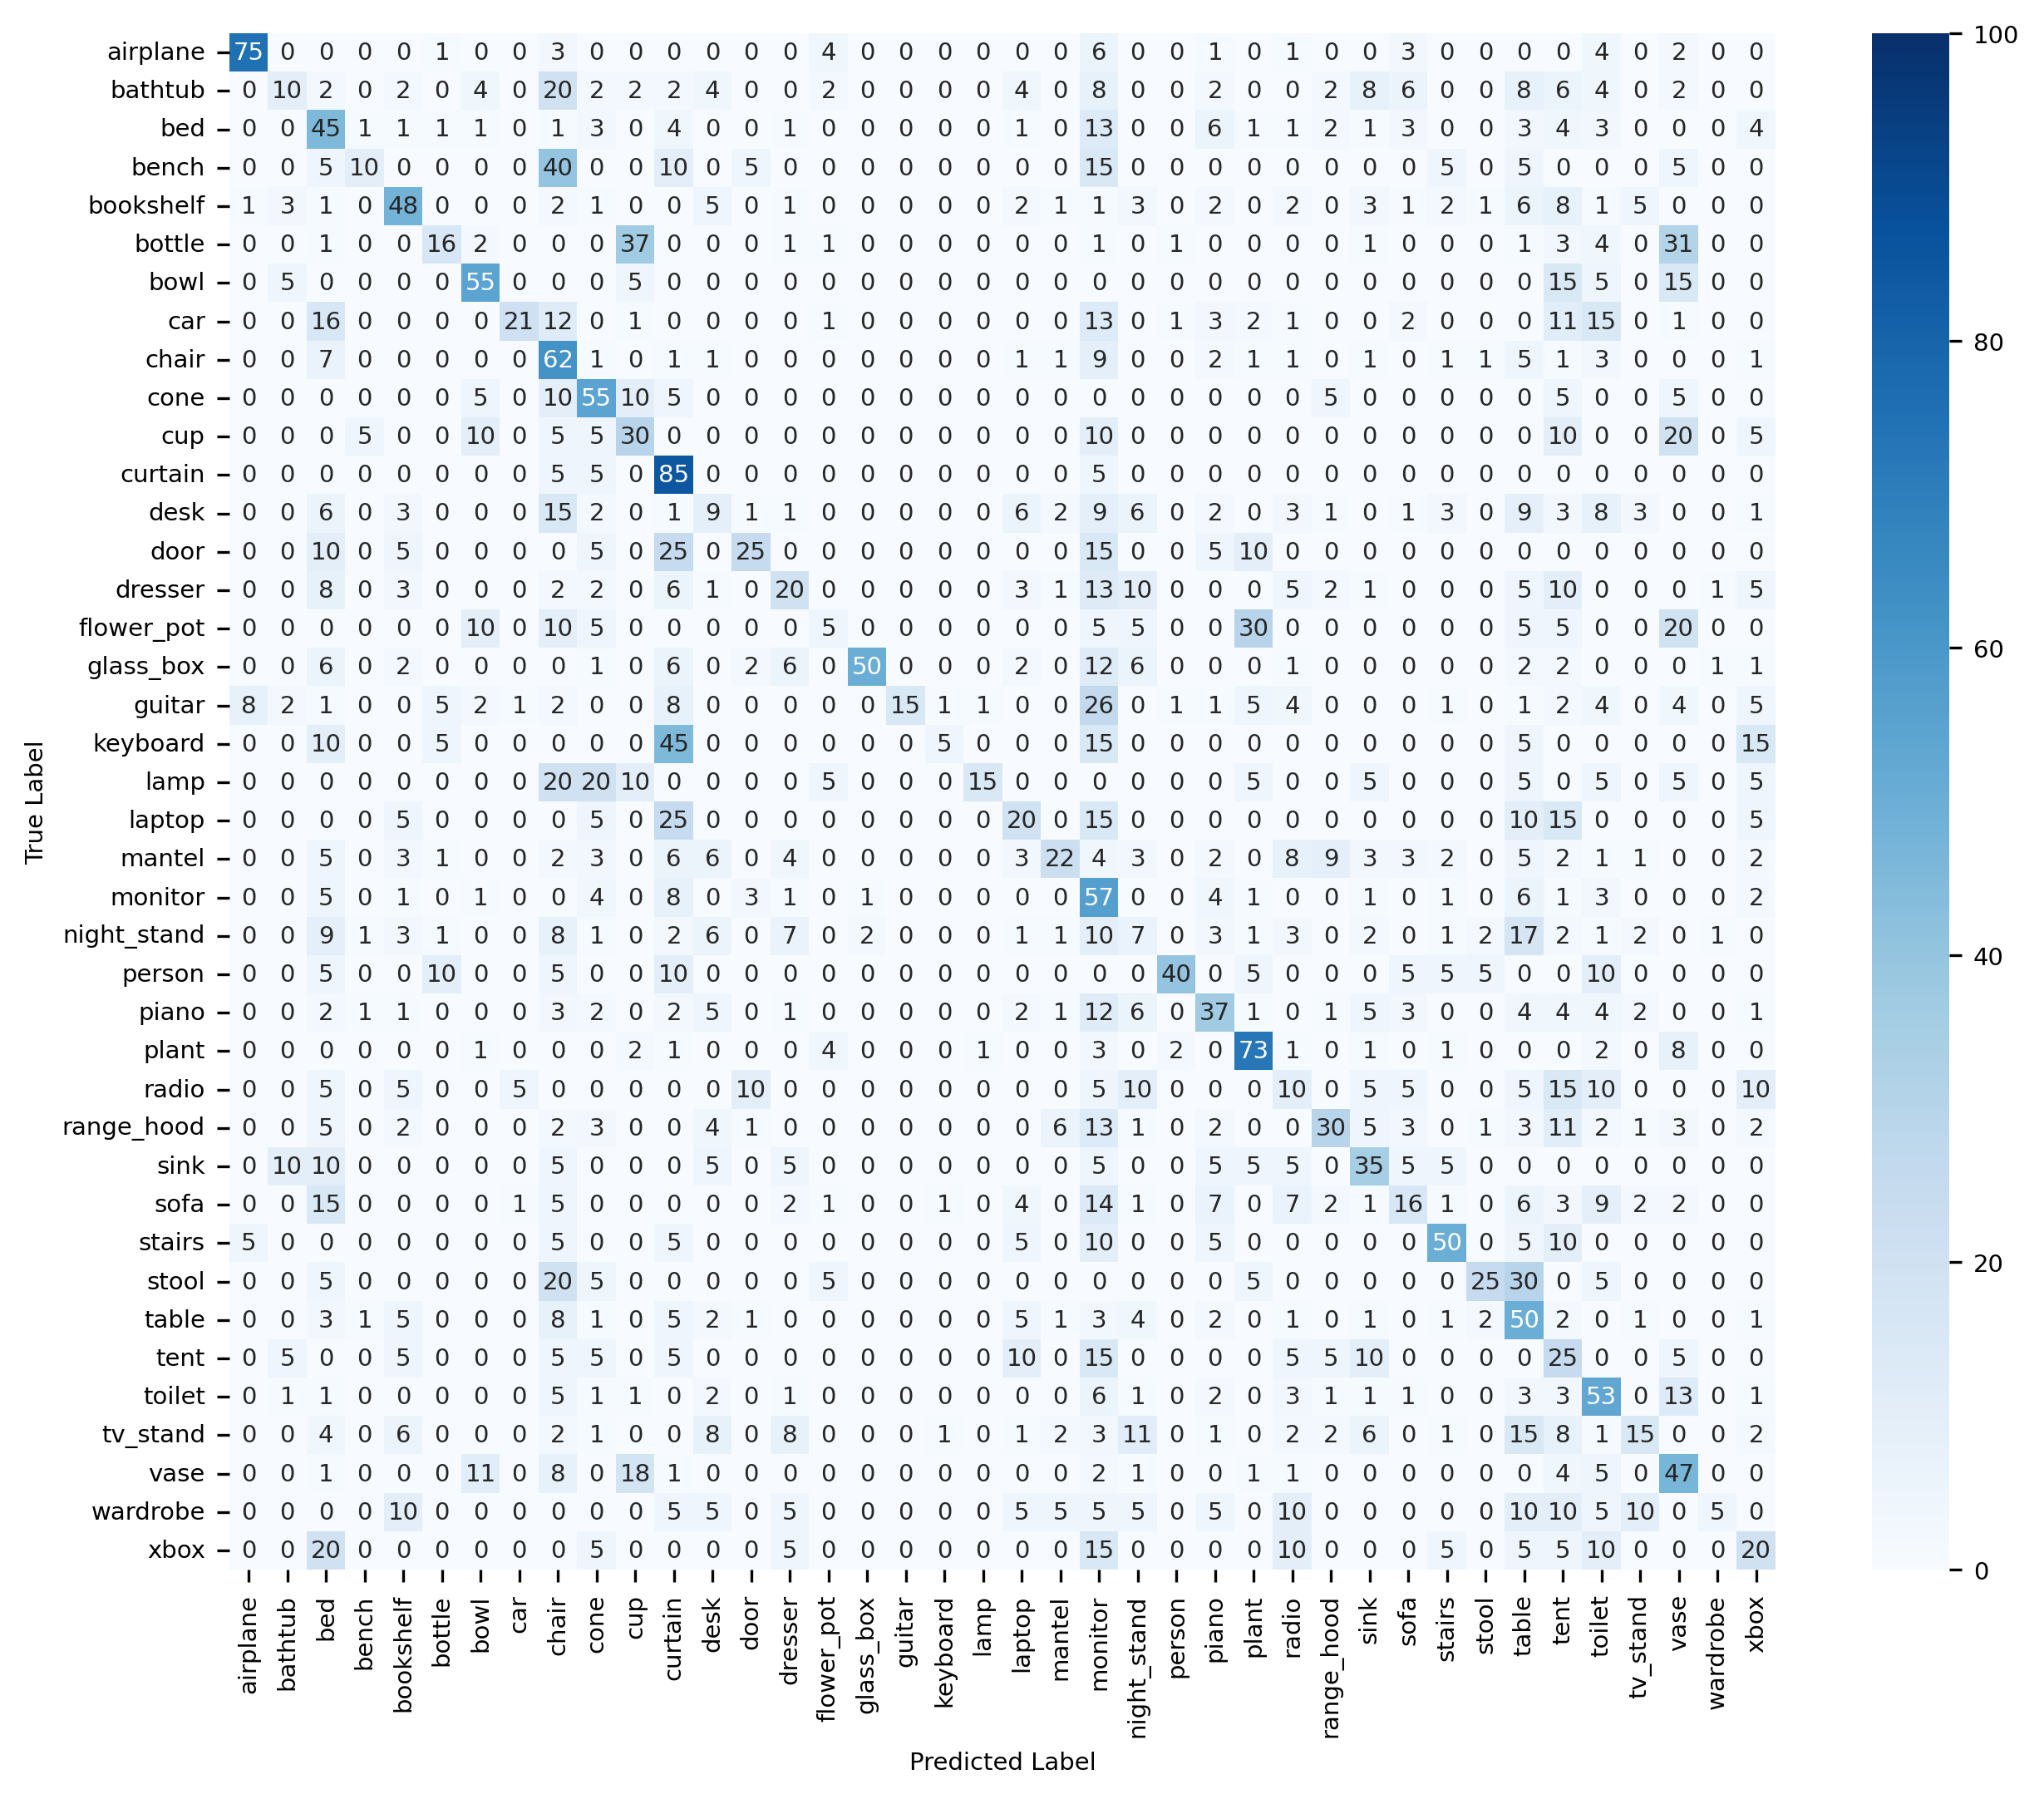

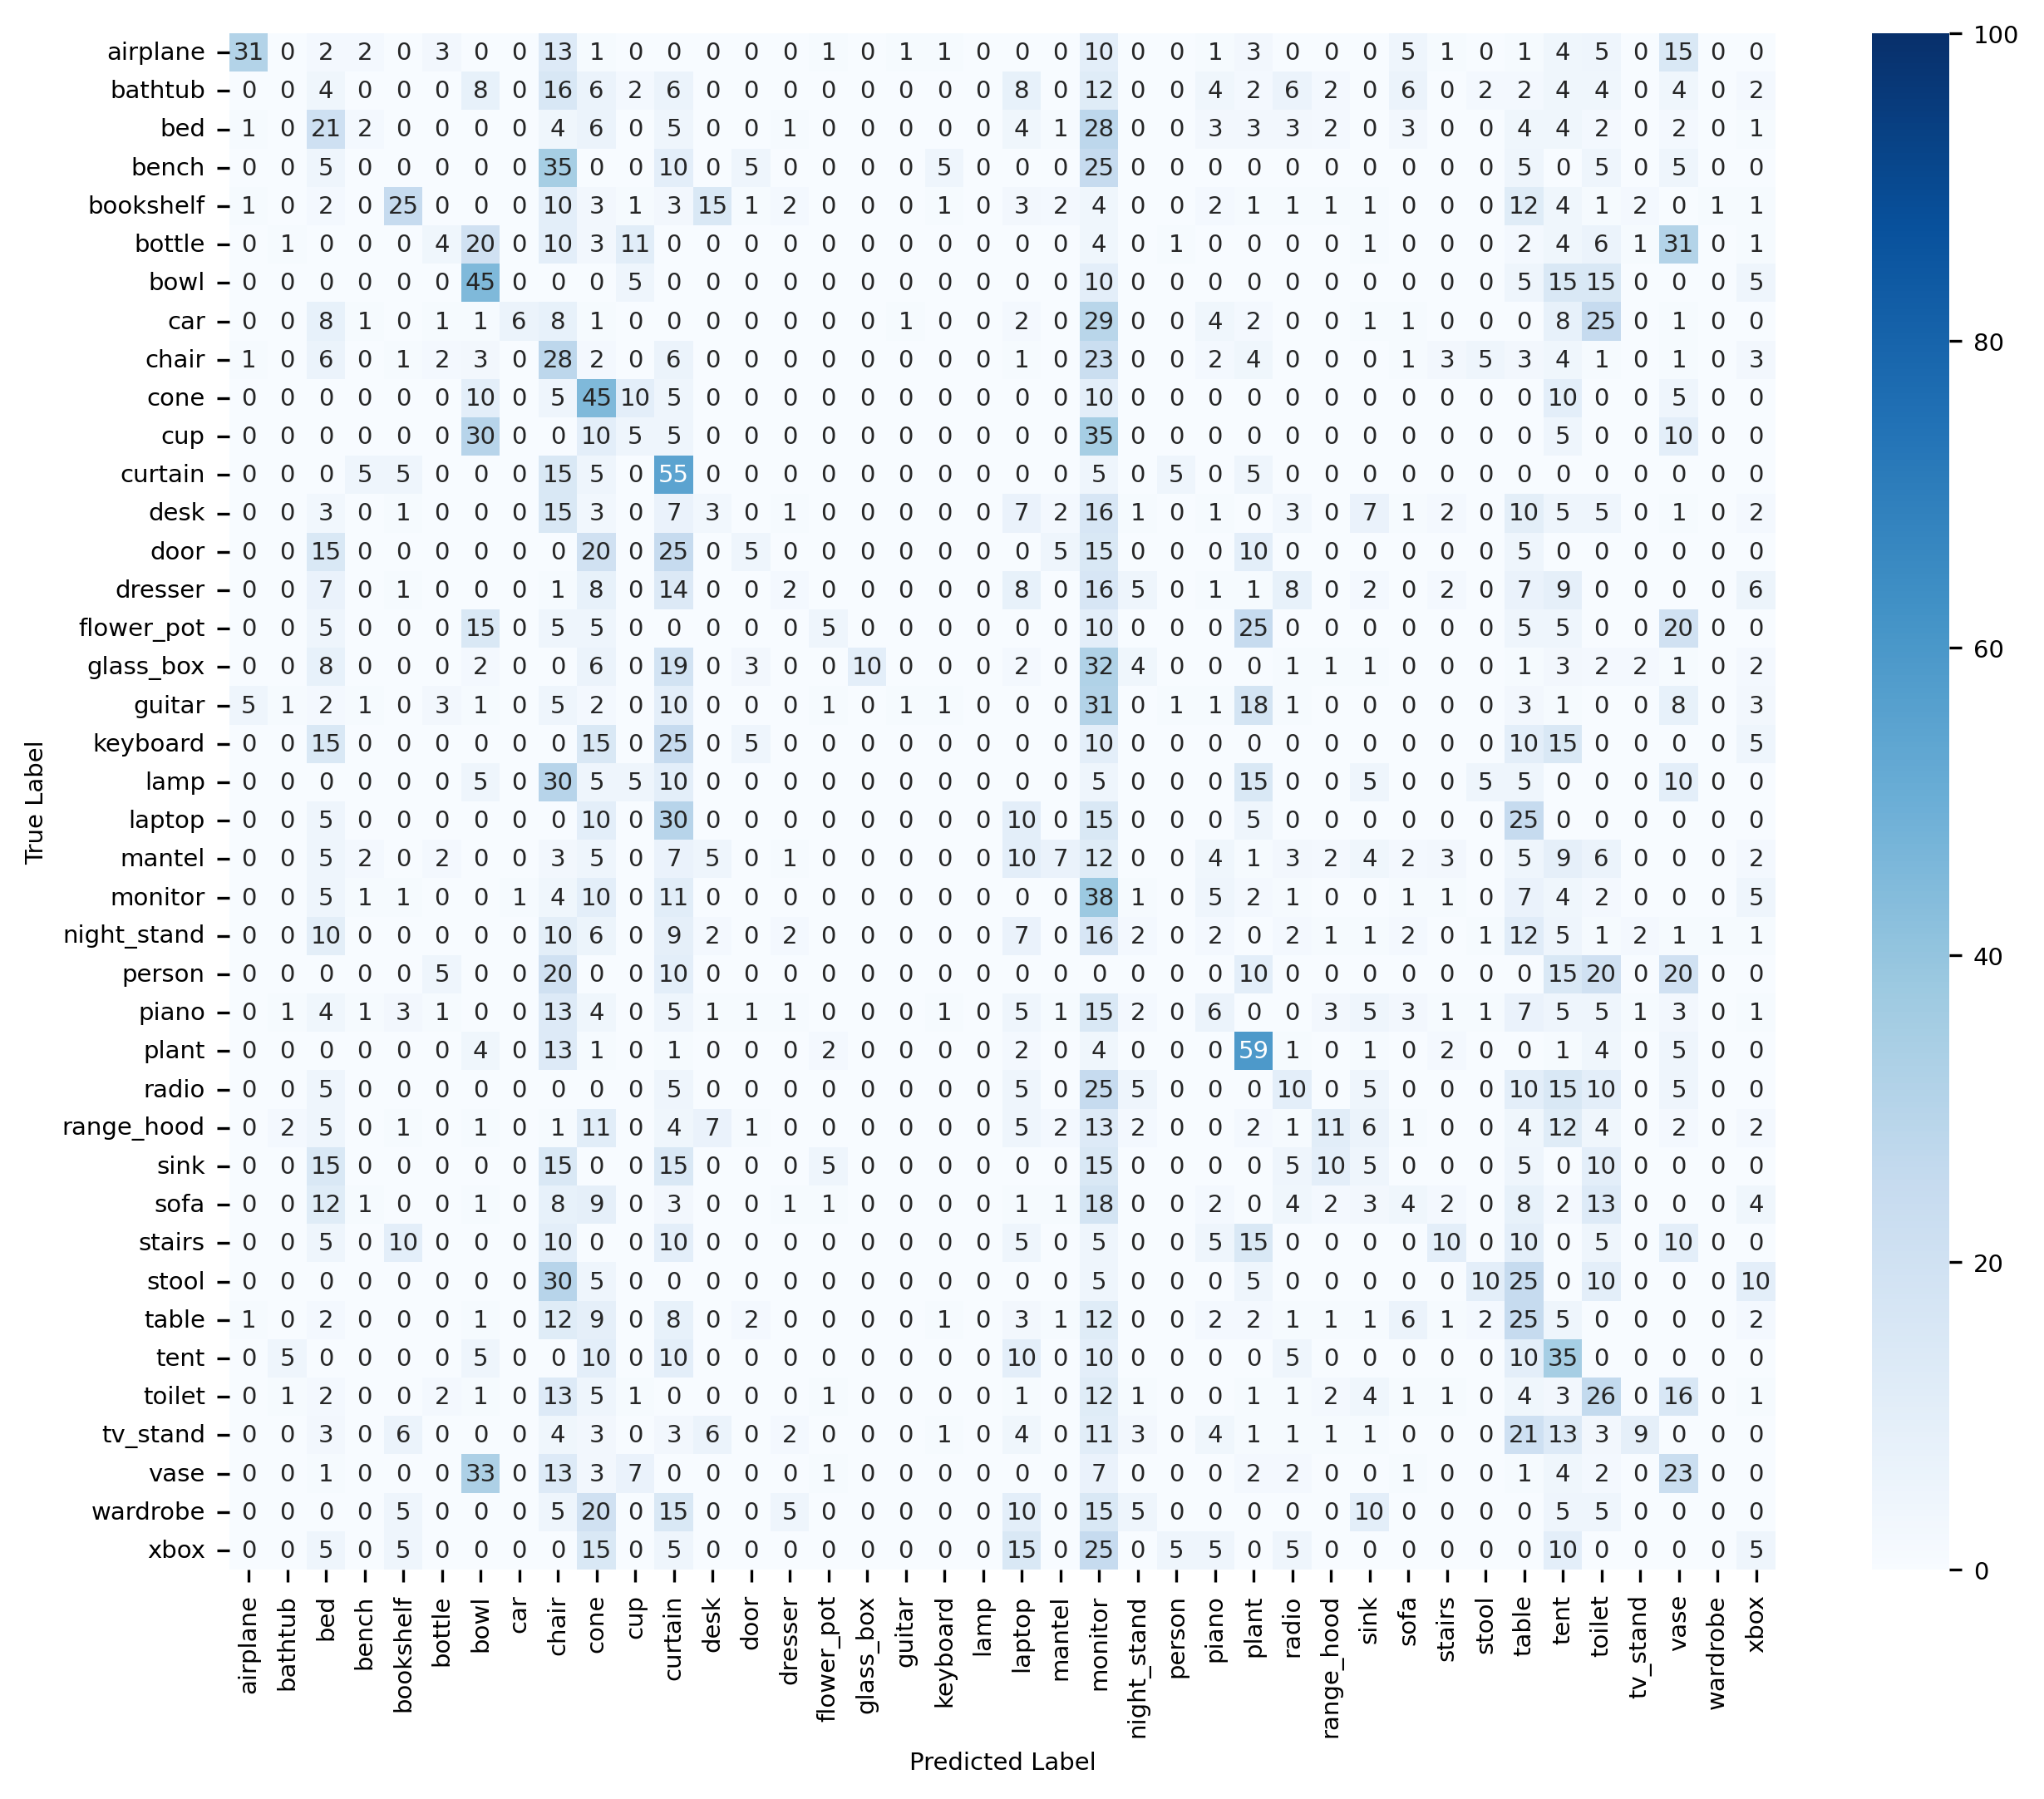

In [14]:
def make_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred, normalize='true') * 100
    fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
    plt.rcParams.update({'font.size': 7})
    ax = sns.heatmap(
        data=cm,
        annot=True,
        fmt='.0f',
        cmap='Blues',
        xticklabels=class_names.values(),
        yticklabels=class_names.values(),
        ax=ax,
        vmax=100,
        vmin=0
      )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    return fig, ax


# Make the confusion matrix for all results, save to output folder
for i, col in enumerate(tqdm(columns, desc='Drawing Confusion Matrices')):
  model, test = col.split('_')
  y_true = result_df['y_true']
  y_pred = result_df[col]
  fig, ax = make_confusion_matrix(y_true, y_pred, class_names)
  ax.set_title('')
  fig.savefig(os.path.join(results_dir, 'cm_pct', f'cm_{model_dicts[target_set]['checkpoints'][i]}_chck_{model}_trained_{test}_tested.png'), bbox_inches='tight')

Drawing Confusion Matrices: 100%|██████████| 12/12 [00:04<00:00,  2.68it/s]


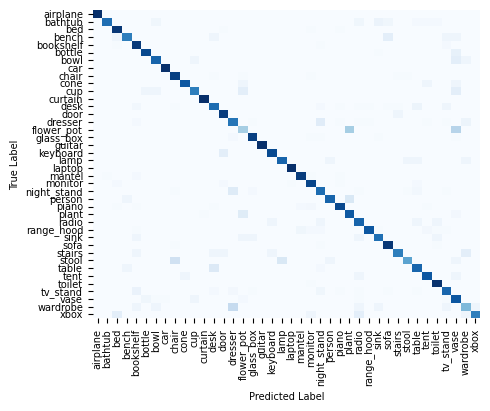

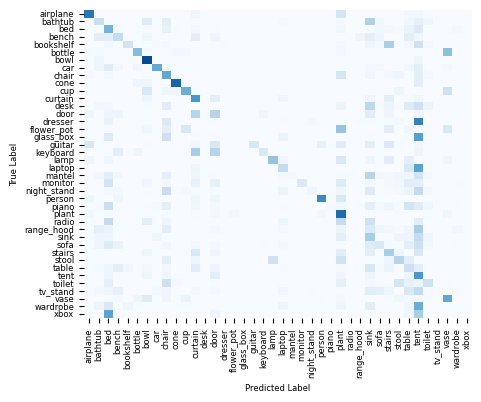

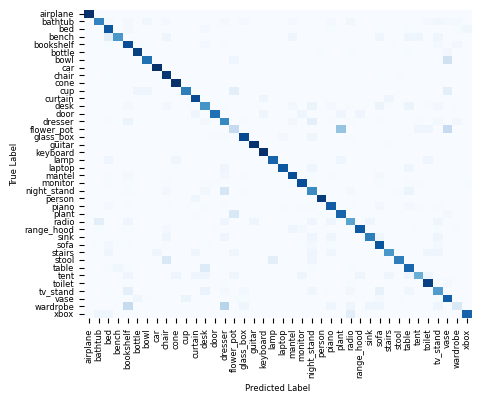

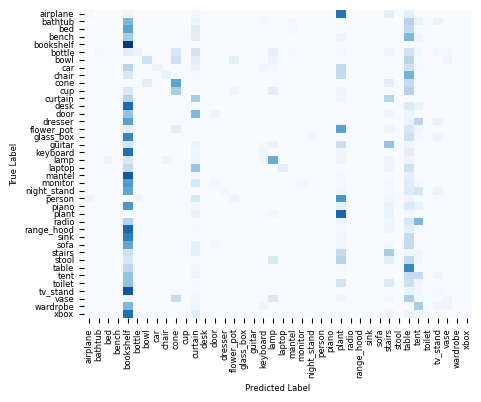

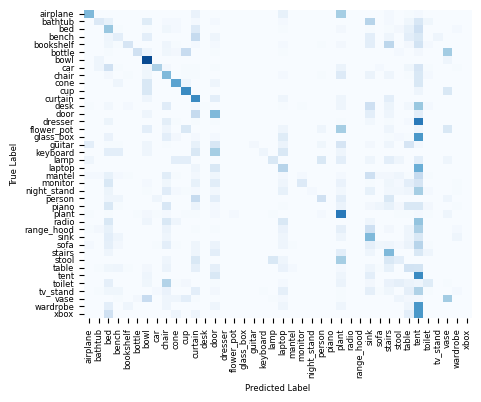

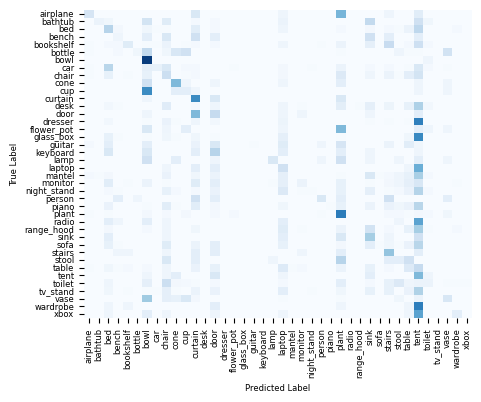

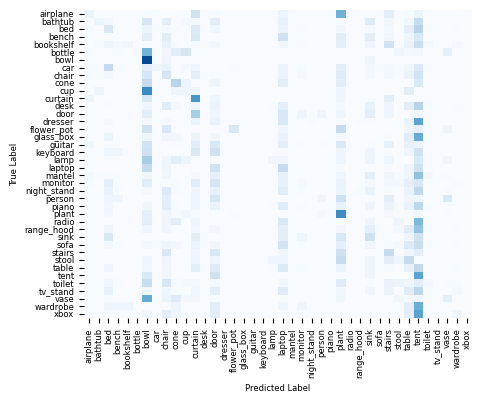

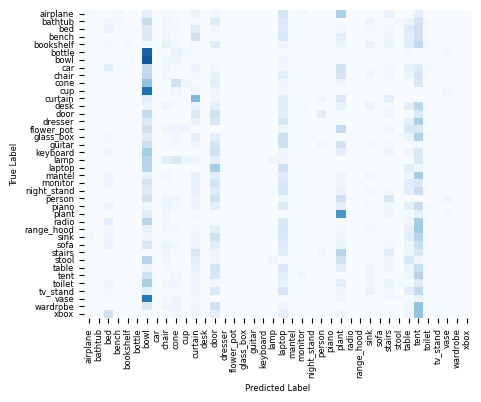

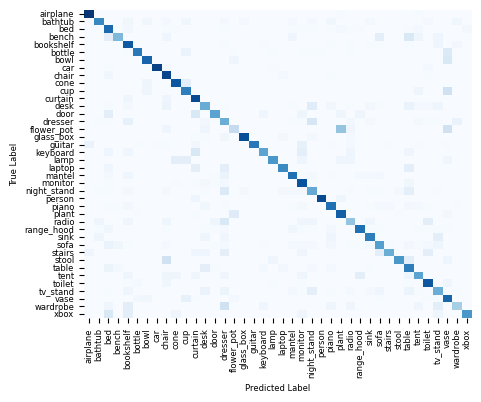

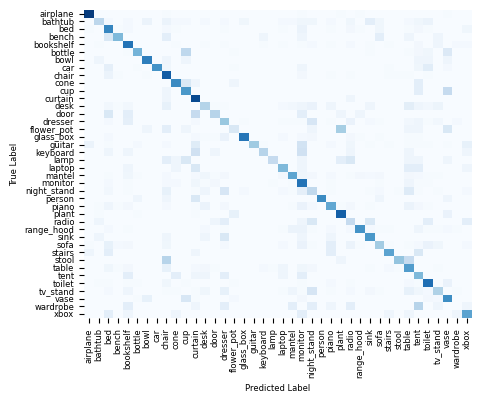

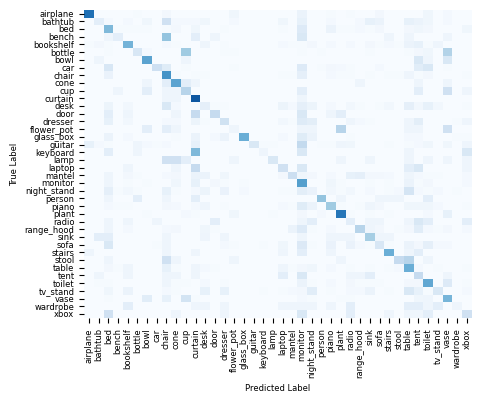

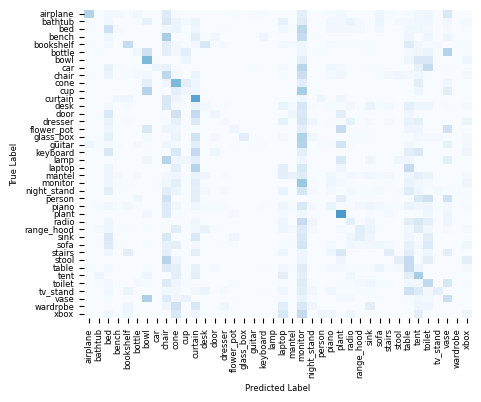

In [15]:
def make_confusion_matrix_small(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred, normalize='true') * 100
    fig, ax = plt.subplots(figsize=(5, 4), dpi=100)
    plt.rcParams.update({'font.size': 6})
    ax = sns.heatmap(
        data=cm,
        annot=False,
        fmt='.0f',
        cmap='Blues',
        xticklabels=class_names.values(),
        yticklabels=class_names.values(),
        ax=ax,
        vmax=100,
        vmin=0,
        cbar=False
      )
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    return fig, ax


# Make the confusion matrix for all results, save to output folder
for i, col in enumerate(tqdm(columns, desc='Drawing Confusion Matrices')):
  model, test = col.split('_')
  y_true = result_df['y_true']
  y_pred = result_df[col]
  fig, ax = make_confusion_matrix_small(y_true, y_pred, class_names)
  ax.set_title('')
  fig.savefig(os.path.join(results_dir, 'cm_pct', f'cm_{model_dicts[target_set]['checkpoints'][i]}_chck_{model}_trained_{test}_tested_small.png'), bbox_inches='tight')